#### **Project Name - Global Vaccination Analytics**

#### **Project Type - Exploratory Data Analysis | Data Cleaning | SQL Database | Healthcare Analytics**

#### **Domain - Public Health and Epidemiology**

#### **Contribution - Individual**

#### **Name - Ishank**

#### **GitHub Link - https://github.com/Ishank2301/Global-Vaccination-Analytics**

#### **Problem Statement**

Analyze global vaccination data to understand trends in vaccination coverage, disease incidence, and effectiveness. The data will be cleaned and stored in a SQL database. Power BI will be used to connect to the SQL database and create interactive dashboards that provide insights on vaccination strategies and their impact on disease control.

#### **Project Summary**

##### **→ What Was Built**

- **Data Pipeline** — Loaded, cleaned, and validated five relational WHO vaccination datasets: Coverage Data (399,859 records), Incidence Rate Data (84,946 records), Reported Cases Data (84,870 records), Vaccine Introduction Data (138,321 records), and Vaccine Schedule Data (8,053 records) spanning 1940 to 2023 across 194+ countries and six WHO regions.

- **Data Cleaning** — Applied systematic preprocessing to all five tables: filtered records to country-level rows only (GROUP == 'COUNTRIES'), dropped rows with missing key identifiers, converted YEAR from float to integer, stripped whitespace from all string columns, capped COVERAGE at 100% to correct administrative overcounting, and standardized INTRO values to binary 'Yes'/'No' categories.

- **Exploratory Data Analysis** — Produced 15 charts across univariate, bivariate, and multivariate analysis covering vaccination coverage distributions, disease incidence trends, WHO regional disparities, vaccine dose drop-off rates, priority vaccine heatmaps, and coverage-incidence correlations. Key findings: AFRO region shows the lowest average vaccination coverage globally; Poliomyelitis and Diphtheria show the greatest post-2000 case reductions; and a clear negative correlation exists between vaccination coverage and disease incidence rates.

- **SQL Database Setup** — Created a normalized SQLite database (vaccination.db) storing all five cleaned tables with proper schemas and primary keys. Implemented seven analytical SQL queries covering WHO regional coverage performance, low-coverage country identification, disease case trends, pre-vs-post vaccination reductions, vaccine introduction disparities, schedule round analysis, and high-incidence country identification.

- **Business Insights** — Identified critical coverage gaps (countries with less than 50% coverage for priority vaccines), quantified DTP dose drop-off rates by WHO region, mapped priority vaccine coverage to the heatmap level, and provided data-driven recommendations for public health resource allocation and vaccination policy decisions.

Global vaccination programs are among the most cost-effective public health interventions in history. This project analyzes WHO-level data across five datasets to uncover trends, regional disparities, and the measurable impact of vaccination on disease burden. All cleaned data is structured in a SQL database ready for Power BI dashboard development.

#### **Business Objectives**

- Assess vaccination coverage across countries and WHO regions to identify high-performing and under-served areas.

- Analyze disease incidence and reported case trends before and after vaccination campaigns to measure program effectiveness.

- Identify regions and countries with critical coverage gaps requiring targeted public health resource allocation.

- Quantify vaccine dose drop-off rates between first and subsequent doses to improve multi-dose schedule completion.

- Build a structured SQL database to support Power BI interactive dashboard development for public health reporting.

- Provide data-driven recommendations for vaccination policy, resource distribution, and disease prevention strategies.

#### **Let's Begin !**

#### **1. Know Your Data**

##### **Import Libraries**

In [1]:
try:
    # Core data handling libraries
    import pandas as pd  # For data manipulation, groupby, merge, and DataFrame operations
    import numpy as np  # For numerical operations, quantile calculations, and array handling

    # Visualization libraries
    import matplotlib.pyplot as plt  # For creating static charts, bar plots, line charts, histograms
    import seaborn as sns  # For statistical data visualizations and correlation heatmaps
    from matplotlib.patches import (
        Patch,
    )  # For building custom legend patches in multi-category charts

    # SQL database connectivity
    import sqlite3  # Built-in Python library for SQLite database creation and querying

    # Utility libraries
    import warnings  # For suppressing non-critical deprecation warnings from pandas and seaborn
    import os  # For creating output directories and managing local file paths

    warnings.filterwarnings(
        "ignore"
    )  # Suppress non-critical warnings to keep output clean

    pd.set_option(
        "display.max_columns", None
    )  # Show all DataFrame columns without truncation
    pd.set_option(
        "display.float_format", "{:.2f}".format
    )  # Display floats to 2 decimal places

    os.makedirs(
        "images", exist_ok=True
    )  # Create directory to store all generated chart PNGs
    os.makedirs(
        "database", exist_ok=True
    )  # Create directory to store the SQLite database file

    print("All libraries imported successfully.")

except ImportError as e:
    # Handle case where a required library is not installed in the Python environment
    print(f"Library import error: {e}")
    print(
        "Please install missing packages using: pip install pandas numpy matplotlib seaborn openpyxl"
    )

except Exception as e:
    # Catch any other unexpected error during the import and setup stage
    print(f"Unexpected error during library import: {e}")

All libraries imported successfully.


##### **Dataset Loading**

In [2]:
# Define the base folder path where all five Excel dataset files are stored
BASE_PATH = "data/"

try:
    # Load Table 1 : Coverage Data — vaccination coverage per country, antigen, and year
    df_coverage = pd.read_excel(BASE_PATH + "coverage-data.xlsx")

    # Load Table 2 : Incidence Rate Data — disease incidence rates per country and year
    df_incidence = pd.read_excel(BASE_PATH + "incidence-rate-data.xlsx")

    # Load Table 3 : Reported Cases Data — number of reported disease cases per country and year
    df_cases = pd.read_excel(BASE_PATH + "reported-cases-data.xlsx")

    # Load Table 4 : Vaccine Introduction Data — whether each vaccine has been introduced per country
    df_intro = pd.read_excel(BASE_PATH + "vaccine-introduction-data.xlsx")

    # Load Table 5 : Vaccine Schedule Data — detailed schedule, target population, and administration info
    df_schedule = pd.read_excel(BASE_PATH + "vaccine-schedule-data.xlsx")

    print("All five datasets loaded successfully.\n")
    print(
        f"Table 1 — Coverage Data : {df_coverage.shape[0]:>7,} rows  x  {df_coverage.shape[1]} columns"
    )
    print(
        f"Table 2 — Incidence Rate Data  : {df_incidence.shape[0]:>7,} rows  x  {df_incidence.shape[1]} columns"
    )
    print(
        f"Table 3 — Reported Cases Data  : {df_cases.shape[0]:>7,} rows  x  {df_cases.shape[1]} columns"
    )
    print(
        f"Table 4 — Vaccine Introduction : {df_intro.shape[0]:>7,} rows  x  {df_intro.shape[1]} columns"
    )
    print(
        f"Table 5 — Vaccine Schedule : {df_schedule.shape[0]:>7,} rows  x  {df_schedule.shape[1]} columns"
    )

except FileNotFoundError as e:
    # Handle case where one or more Excel files cannot be found at the given path
    print(f"File not found: {e}")
    print(
        "Ensure all dataset files are placed inside the 'Vaccination project/' directory."
    )

except Exception as e:
    # Catch any other unexpected error during dataset loading
    print(f"Unexpected error while loading datasets: {e}")

All five datasets loaded successfully.

Table 1 — Coverage Data : 399,859 rows  x  11 columns
Table 2 — Incidence Rate Data  :  84,946 rows  x  8 columns
Table 3 — Reported Cases Data  :  84,870 rows  x  7 columns
Table 4 — Vaccine Introduction : 138,321 rows  x  6 columns
Table 5 — Vaccine Schedule :   8,053 rows  x  12 columns


##### **Dataset First View**

In [3]:
try:
    # Preview the first five rows of each dataset to understand its structure and content
    print("=== TABLE 1 : COVERAGE DATA ===")
    display(df_coverage.head())  # Top 5 rows of coverage data

    print("\n=== TABLE 2 : INCIDENCE RATE DATA ===")
    display(df_incidence.head())  # Top 5 rows of incidence rate data

    print("\n=== TABLE 3 : REPORTED CASES DATA ===")
    display(df_cases.head())  # Top 5 rows of reported cases data

    print("\n=== TABLE 4 : VACCINE INTRODUCTION DATA ===")
    display(df_intro.head())  # Top 5 rows of vaccine introduction data

    print("\n=== TABLE 5 : VACCINE SCHEDULE DATA ===")
    display(df_schedule.head())  # Top 5 rows of vaccine schedule data

except NameError as e:
    # Handle case where a dataset variable was not loaded due to a prior loading error
    print(
        f"Dataset not found — check that all five files were loaded successfully: {e}"
    )

except Exception as e:
    # Catch any unexpected error during first view display
    print(f"Error displaying dataset first view: {e}")

=== TABLE 1 : COVERAGE DATA ===


,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.00,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.00,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.00,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.00,945.00,90.52
3,COUNTRIES,ABW,Aruba,2023.00,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",OFFICIAL,Official coverage,NaN,NaN,90.52
4,COUNTRIES,ABW,Aruba,2023.00,DIPHCV5,"Diphtheria-containing vaccine, 5th dose (2nd b...",ADMIN,Administrative coverage,1219.00,1008.00,82.69



=== TABLE 2 : INCIDENCE RATE DATA ===


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023.00,CRS,Congenital rubella syndrome,"per 10,000 live births",0.00
1,COUNTRIES,ABW,Aruba,2023.00,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.00
2,COUNTRIES,ABW,Aruba,2023.00,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.30
3,COUNTRIES,ABW,Aruba,2023.00,MEASLES,Measles,"per 1,000,000 total population",NaN
4,COUNTRIES,ABW,Aruba,2023.00,MUMPS,Mumps,"per 1,000,000 total population",0.00



=== TABLE 3 : REPORTED CASES DATA ===


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
0,COUNTRIES,ABW,Aruba,2023.00,CRS,Congenital rubella syndrome,0.00
1,COUNTRIES,ABW,Aruba,2023.00,DIPHTHERIA,Diphtheria,0.00
2,COUNTRIES,ABW,Aruba,2023.00,INVASIVE_MENING,Invasive meningococcal disease,1.00
3,COUNTRIES,ABW,Aruba,2023.00,MEASLES,Measles,NaN
4,COUNTRIES,ABW,Aruba,2023.00,MUMPS,Mumps,0.00



=== TABLE 4 : VACCINE INTRODUCTION DATA ===


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023.00,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.00,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.00,Hepatitis B vaccine,Yes
3,AFG,Afghanistan,EMRO,2023.00,HepB birth dose,Yes
4,AFG,Afghanistan,EMRO,2023.00,Hib (Haemophilus influenzae type B) vaccine,Yes



=== TABLE 5 : VACCINE SCHEDULE DATA ===


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
0,ABW,Aruba,AMRO,2023.00,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.00,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.00,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.00,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.00,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.00,NaN,General/routine,NATIONAL,M6,NaN
3,ABW,Aruba,AMRO,2023.00,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,4.00,B_2YL_W,General/routine,NATIONAL,M15,NaN
4,ABW,Aruba,AMRO,2023.00,DTAPIPV,DTaP-IPV (acellular) vaccine,5.00,B_CHILD_W,General/routine,NATIONAL,Y4,NaN


##### **Dataset Rows and Columns Count**

In [4]:
try:
    # Store all five datasets in a dictionary for convenient iteration across sections
    datasets = {
        "Coverage Data": df_coverage,  # Table 1: vaccination coverage
        "Incidence Rate Data": df_incidence,  # Table 2: disease incidence rates
        "Reported Cases Data": df_cases,  # Table 3: reported disease cases
        "Vaccine Introduction": df_intro,  # Table 4: vaccine introduction status
        "Vaccine Schedule": df_schedule,  # Table 5: vaccine schedule details
    }

    # Print exact row and column counts for every dataset in a formatted layout
    print(f"{'Dataset':<25} {'Rows':>10} {'Columns':>10}")
    print("-" * 47)

    for name, df in datasets.items():
        rows, cols = df.shape  # Unpack shape tuple into row and column counts
        print(f"{name:<25} {rows:>10,} {cols:>10}")

except NameError as e:
    # Handle case where a dataset variable is undefined due to a prior loading error
    print(f"Dataset variable not found: {e}")

except Exception as e:
    # Catch any unexpected error during shape reporting
    print(f"Error printing dataset dimensions: {e}")

Dataset                         Rows    Columns
-----------------------------------------------
Coverage Data                399,859         11
Incidence Rate Data           84,946          8
Reported Cases Data           84,870          7
Vaccine Introduction         138,321          6
Vaccine Schedule               8,053         12


##### **Dataset Information**

In [5]:
try:
    # Show column names, non-null counts, and data types for every dataset
    for name, df in datasets.items():
        print(f"=== {name.upper()} ===")
        df.info()  # Prints dtype, non-null count, and memory usage per column
        print()

except NameError as e:
    # Handle case where 'datasets' dict was not created due to a prior error
    print(f"datasets dictionary not found: {e}")

except Exception as e:
    # Catch any unexpected error during info display
    print(f"Error displaying dataset info: {e}")

=== COVERAGE DATA ===
<class 'pandas.DataFrame'>
RangeIndex: 399859 entries, 0 to 399858
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   GROUP                          399859 non-null  str    
 1   CODE                           399858 non-null  str    
 2   NAME                           398584 non-null  str    
 3   YEAR                           399858 non-null  float64
 4   ANTIGEN                        399858 non-null  str    
 5   ANTIGEN_DESCRIPTION            399858 non-null  str    
 6   COVERAGE_CATEGORY              399858 non-null  str    
 7   COVERAGE_CATEGORY_DESCRIPTION  399858 non-null  str    
 8   TARGET_NUMBER                  79030 non-null   float64
 9   DOSES                          79327 non-null   float64
 10  COVERAGE                       230477 non-null  float64
dtypes: float64(4), str(7)
memory usage: 33.6 MB

=== INCIDENCE RATE DATA ===
<class 

##### **Duplicate Values**

In [6]:
try:
    # Count fully duplicated rows (exact copies of another row) across all five datasets
    print(f"{'Dataset':<25} {'Duplicate Rows':>15}")
    print("-" * 42)

    for name, df in datasets.items():
        dup_count = df.duplicated().sum()  # Count rows that are exact duplicates
        print(f"{name:<25} {dup_count:>15,}")

except NameError as e:
    # Handle case where 'datasets' dict is undefined
    print(f"datasets dictionary not found: {e}")

except Exception as e:
    # Catch any unexpected error during duplicate count
    print(f"Error checking duplicate values: {e}")

Dataset                    Duplicate Rows
------------------------------------------
Coverage Data                           0
Incidence Rate Data                     0
Reported Cases Data                     0
Vaccine Introduction                    0
Vaccine Schedule                        0


##### **Missing Values / Null Values**

In [7]:
try:
    # Count and display missing values per column for all five datasets
    for name, df in datasets.items():
        missing = df.isnull().sum()  # Null count per column
        missing = missing[missing > 0]  # Keep only columns with nulls
        missing_pct = (missing / len(df) * 100).round(2)  # Compute missing percentage

        print(f"=== {name.upper()} ===")

        if missing.empty:
            print("  No missing values found.\n")  # No nulls present in this table
        else:
            print(f"  {'Column':<40} {'Missing':>10} {'%':>8}")
            print("  " + "-" * 60)
            for col in missing.index:
                print(f"  {col:<40} {missing[col]:>10,} {missing_pct[col]:>7.2f}%")
            print()

except NameError as e:
    # Handle case where 'datasets' dict is undefined
    print(f"datasets dictionary not found: {e}")

except Exception as e:
    # Catch any unexpected error during missing value analysis
    print(f"Error analysing missing values: {e}")

=== COVERAGE DATA ===
  Column                                      Missing        %
  ------------------------------------------------------------
  CODE                                              1    0.00%
  NAME                                          1,275    0.32%
  YEAR                                              1    0.00%
  ANTIGEN                                           1    0.00%
  ANTIGEN_DESCRIPTION                               1    0.00%
  COVERAGE_CATEGORY                                 1    0.00%
  COVERAGE_CATEGORY_DESCRIPTION                     1    0.00%
  TARGET_NUMBER                               320,829   80.24%
  DOSES                                       320,532   80.16%
  COVERAGE                                    169,382   42.36%

=== INCIDENCE RATE DATA ===
  Column                                      Missing        %
  ------------------------------------------------------------
  CODE                                              1    0.00%
  NA

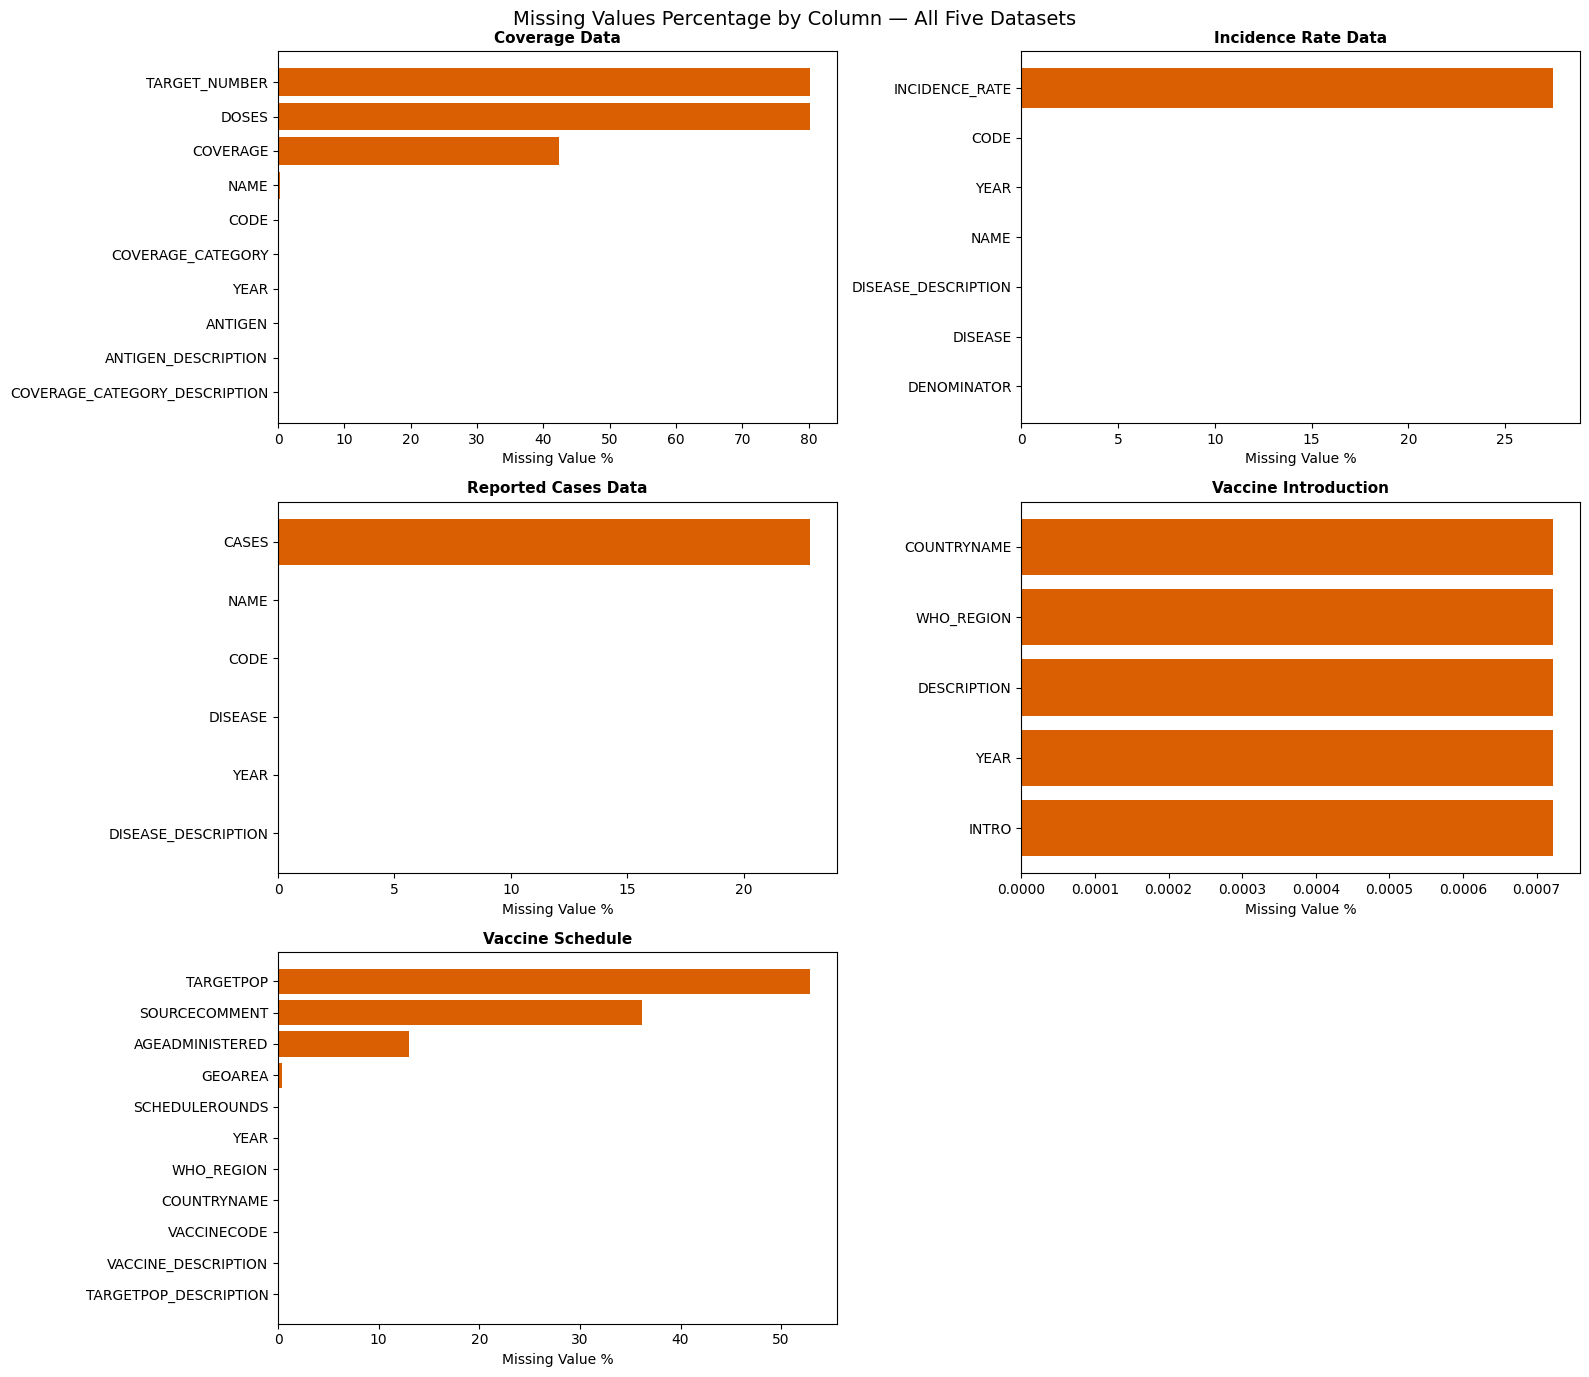

In [8]:
try:
    # Visualize missing value percentages as a horizontal bar chart grid
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))  # 3-row x 2-column subplot grid

    axes_flat = axes.flatten()  # Flatten to 1D list for indexed access
    dataset_list = list(datasets.items())  # Convert dict to indexed list

    for i, (name, df) in enumerate(dataset_list):
        ax = axes_flat[i]  # Get subplot axis for this dataset

        # Compute missing value percentage per column
        missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
        missing_pct = missing_pct[missing_pct > 0]  # Only columns with missing values

        if missing_pct.empty:
            # No missing values — display a text label instead of a bar chart
            ax.text(
                0.5, 0.5, "No Missing Values", ha="center", va="center", fontsize=12
            )
            ax.set_title(name, fontsize=11, fontweight="bold")
            ax.axis("off")  # Hide axis lines when nothing to plot
        else:
            # Horizontal bar chart showing missing percentage per column
            ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color="#d95f02")
            ax.set_xlabel("Missing Value %")  # X-axis label
            ax.set_title(name, fontsize=11, fontweight="bold")  # Dataset name as title

    axes_flat[5].axis("off")  # Hide the unused 6th subplot (5 datasets, 6 grid cells)

    plt.suptitle("Missing Values Percentage by Column — All Five Datasets", fontsize=14)
    plt.tight_layout()  # Adjust spacing to prevent label overlap
    plt.savefig("images/missing_values_all_tables.png", dpi=300, bbox_inches="tight")
    plt.show()

except NameError as e:
    # Handle case where 'datasets' dict or matplotlib is not available
    print(f"Variable not found for missing values chart: {e}")

except Exception as e:
    # Catch any unexpected error during bar chart generation
    print(f"Error generating missing values chart: {e}")

##### **Key Insights**

- **Coverage Data** has the most severe missing value problem: TARGET_NUMBER (80.2%), DOSES (80.2%), and COVERAGE (42.4%) are all heavily incomplete, reflecting that many countries report vaccination status without administrative count details. COVERAGE is the primary analysis column and only non-null records will be used.

- **Incidence Rate Data** has 27.5% missing INCIDENCE_RATE values, which reflects under-reporting gaps in national disease surveillance systems, particularly in lower-income countries.

- **Reported Cases Data** has 22.9% missing CASES values, similarly reflecting inconsistent disease reporting infrastructure across WHO regions.

- **Vaccine Introduction Data** is the most complete table with only singleton header/footer null rows, making it the most reliable reference for country-vaccine-region mapping.

- **Vaccine Schedule Data** has 52.9% missing TARGETPOP values and 13.0% missing AGEADMINISTERED, as schedule administration details are inconsistently documented across countries and years.

- The time range across datasets spans **1940 to 2023**, though systematic WHO-standardized coverage data is concentrated from the **1980s onwards** following the Expanded Programme on Immunization (EPI) launch in 1974.

#### **2. Understanding Variables**

##### **Dataset Columns**

In [9]:
try:
    # Print all column names with their data types for every dataset
    for name, df in datasets.items():
        print(f"=== {name.upper()} ===")
        for col in df.columns:
            print(f"  {col:<45} : {str(df[col].dtype)}")  # Name aligned with dtype
        print()

except NameError as e:
    # Handle case where 'datasets' dict is undefined
    print(f"datasets dictionary not found: {e}")

except Exception as e:
    # Catch any unexpected error during column listing
    print(f"Error listing dataset columns: {e}")

=== COVERAGE DATA ===
  GROUP                                         : str
  CODE                                          : str
  NAME                                          : str
  YEAR                                          : float64
  ANTIGEN                                       : str
  ANTIGEN_DESCRIPTION                           : str
  COVERAGE_CATEGORY                             : str
  COVERAGE_CATEGORY_DESCRIPTION                 : str
  TARGET_NUMBER                                 : float64
  DOSES                                         : float64
  COVERAGE                                      : float64

=== INCIDENCE RATE DATA ===
  GROUP                                         : str
  CODE                                          : str
  NAME                                          : str
  YEAR                                          : float64
  DISEASE                                       : str
  DISEASE_DESCRIPTION                           : str
  DENOMINAT

##### **Describe Dataset**

In [10]:
try:
    # Statistical summary for all five datasets including both numeric and object columns
    for name, df in datasets.items():
        print(f"=== {name.upper()} ===")
        display(df.describe(include="all").T)  # Transpose so columns become rows
        print()

except NameError as e:
    # Handle case where 'datasets' dict is undefined
    print(f"datasets dictionary not found: {e}")

except Exception as e:
    # Catch any unexpected error during statistical summary generation
    print(f"Error generating descriptive statistics: {e}")

=== COVERAGE DATA ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,399859,9,COUNTRIES,381041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,399858,245,ETH,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,398584,242,Ethiopia,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,399858.00,NaN,NaN,NaN,2009.21,11.72,1980.00,2002.00,2012.00,2019.00,2023.00
ANTIGEN,399858,69,DTPCV3,26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANTIGEN_DESCRIPTION,399858,69,"DTP-containing vaccine, 3rd dose",26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY,399858,5,ADMIN,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY_DESCRIPTION,399858,5,Administrative coverage,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TARGET_NUMBER,79030.00,NaN,NaN,NaN,278019173.76,54152442883.35,0.00,32814.00,317871.50,2493048.00,11700000000000.00
DOSES,79327.00,NaN,NaN,NaN,3467241.12,11256763.03,-222288203.00,14469.00,152212.00,971018.50,126605212.00



=== INCIDENCE RATE DATA ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,84946,4,COUNTRIES,82054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,84945,221,GLOBAL,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,84945,221,Global,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,84945.00,NaN,NaN,NaN,2004.10,12.60,1980.00,1994.00,2005.00,2015.00,2023.00
DISEASE,84945,13,MEASLES,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISEASE_DESCRIPTION,84945,13,Measles,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DENOMINATOR,84945,5,"per 1,000,000 total population",61480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INCIDENCE_RATE,61584.00,NaN,NaN,NaN,109.45,992.28,0.00,0.00,0.00,4.60,69101.30



=== REPORTED CASES DATA ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,84870,4,COUNTRIES,82054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,84869,221,GLOBAL,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,84869,221,Global,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,84869.00,NaN,NaN,NaN,2004.11,12.59,1980.00,1994.00,2005.00,2015.00,2023.00
DISEASE,84869,13,MEASLES,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISEASE_DESCRIPTION,84869,13,Measles,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CASES,65470.00,NaN,NaN,NaN,4472.41,61144.55,0.00,0.00,1.00,63.00,4583555.00



=== VACCINE INTRODUCTION ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ISO_3_CODE,138321,195,AFG,747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COUNTRYNAME,138320,194,Afghanistan,747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WHO_REGION,138320,6,EURO,34523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,138320.00,NaN,NaN,NaN,2001.27,17.68,1940.00,1992.00,2006.00,2015.00,2023.00
DESCRIPTION,138320,21,Seasonal Influenza vaccine,14715,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INTRO,138320,9,No,97695,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== VACCINE SCHEDULE ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ISO_3_CODE,8053,214,RUS,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COUNTRYNAME,8052,213,Russian Federation,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WHO_REGION,8052,6,EURO,2156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,8052.00,NaN,NaN,NaN,2022.94,0.44,2019.00,2023.00,2023.00,2023.00,2023.00
VACCINECODE,8052,86,TD_S,967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VACCINE_DESCRIPTION,8052,86,Td (Tetanus toxoid and diphtheria for older ch...,967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULEROUNDS,8052.00,NaN,NaN,NaN,2.05,1.32,1.00,1.00,2.00,3.00,7.00
TARGETPOP,3795,15,RISKGROUPS,1247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TARGETPOP_DESCRIPTION,8052,10,General/routine,4695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEOAREA,8022,2,NATIONAL,7788,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### **Variables Description**

**Table 1 : Coverage Data**

| Column | Type | Description |
|--------|------|-------------|
| `GROUP` | object | Categorization of records; here it represents 'COUNTRIES' (may also contain regional aggregates) |
| `CODE` | object | Unique ISO Alpha-3 country code (e.g., IND, USA, KEN) |
| `NAME` | object | Full country name |
| `YEAR` | float64 | Calendar year of the coverage record |
| `ANTIGEN` | object | Vaccine antigen code (e.g., BCG, MCV1, DTPCV3, POL3, HEPB3) |
| `ANTIGEN_DESCRIPTION` | object | Full descriptive name of the vaccine antigen |
| `COVERAGE_CATEGORY` | object | Coverage reporting category: ADMIN, OFFICIAL, WUENIC, HPV, or PAB |
| `COVERAGE_CATEGORY_DESCRIPTION` | object | Expanded description of the coverage reporting category |
| `TARGET_NUMBER` | float64 | Number of individuals targeted for vaccination in that year |
| `DOSES` | float64 | Total number of vaccine doses administered |
| `COVERAGE` | float64 | Percentage of the target population that received the vaccine (0–100+) |

**Table 2 : Incidence Rate Data**

| Column | Type | Description |
|--------|------|-------------|
| `GROUP` | object | Categorization; represents 'COUNTRIES' |
| `CODE` | object | ISO Alpha-3 country code |
| `NAME` | object | Country name |
| `YEAR` | float64 | Year of the incidence record |
| `DISEASE` | object | Short disease code (e.g., MEASLES, DIPHTERIA, POLIO) |
| `DISEASE_DESCRIPTION` | object | Full disease name (e.g., Measles, Diphtheria, Poliomyelitis) |
| `DENOMINATOR` | object | Population basis used: per 10,000 live births or per 1,000,000 total population |
| `INCIDENCE_RATE` | float64 | Number of disease cases per the specified population unit |

**Table 3 : Reported Cases Data**

| Column | Type | Description |
|--------|------|-------------|
| `GROUP` | object | Categorization; represents 'COUNTRIES' |
| `CODE` | object | ISO Alpha-3 country code |
| `NAME` | object | Country name |
| `YEAR` | float64 | Year of the case report |
| `DISEASE` | object | Disease code |
| `DISEASE_DESCRIPTION` | object | Full disease name |
| `CASES` | float64 | Number of officially reported disease cases for that country and year |

**Table 4 : Vaccine Introduction Data**

| Column | Type | Description |
|--------|------|-------------|
| `ISO_3_CODE` | object | ISO Alpha-3 country code |
| `COUNTRYNAME` | object | Country name |
| `WHO_REGION` | object | WHO region code: AFRO, AMRO, EMRO, EURO, SEARO, WPRO |
| `YEAR` | float64 | Year of the introduction record |
| `DESCRIPTION` | object | Vaccine name or type (e.g., Hepatitis B vaccine, Rotavirus vaccine) |
| `INTRO` | object | Whether the vaccine has been introduced: 'Yes' or 'No' |

**Table 5 : Vaccine Schedule Data**

| Column | Type | Description |
|--------|------|-------------|
| `ISO_3_CODE` | object | ISO Alpha-3 country code |
| `COUNTRYNAME` | object | Country name |
| `WHO_REGION` | object | WHO region code |
| `YEAR` | float64 | Year of the schedule record |
| `VACCINECODE` | object | Vaccine code used in the national schedule |
| `VACCINE_DESCRIPTION` | object | Vaccine name and details |
| `SCHEDULEROUNDS` | float64 | Dose round number in the vaccination schedule |
| `TARGETPOP` | object | Target population code for that dose |
| `TARGETPOP_DESCRIPTION` | object | Detailed description of the target population |
| `GEOAREA` | object | Geographic area of administration (NATIONAL or sub-national) |
| `AGEADMINISTERED` | object | Age or time at which the vaccine dose is administered |
| `SOURCECOMMENT` | object | Additional notes or data source context |

##### **Checking Unique Values for Each Variable**

In [11]:
try:
    # Print unique value counts per column for all five datasets
    for name, df in datasets.items():
        print(f"=== {name.upper()} ===")
        for col in df.columns:
            print(
                f"  {col:<45} : {df[col].nunique()} unique values"
            )  # nunique counts distinct values
        print("-" * 60)
        print()

except NameError as e:
    # Handle case where 'datasets' dict is undefined
    print(f"datasets dictionary not found: {e}")

except Exception as e:
    # Catch any unexpected error during unique value counting
    print(f"Error counting unique values: {e}")

=== COVERAGE DATA ===
  GROUP                                         : 9 unique values
  CODE                                          : 245 unique values
  NAME                                          : 242 unique values
  YEAR                                          : 44 unique values
  ANTIGEN                                       : 69 unique values
  ANTIGEN_DESCRIPTION                           : 69 unique values
  COVERAGE_CATEGORY                             : 5 unique values
  COVERAGE_CATEGORY_DESCRIPTION                 : 5 unique values
  TARGET_NUMBER                                 : 24395 unique values
  DOSES                                         : 53792 unique values
  COVERAGE                                      : 7602 unique values
------------------------------------------------------------

=== INCIDENCE RATE DATA ===
  GROUP                                         : 4 unique values
  CODE                                          : 221 unique values
  NAME    

##### **Key Insights**

- **Coverage Data** tracks **70 unique antigens** across **194 countries** from 1980 to 2023, making it the most granular and analytically rich table in the dataset.

- **COVERAGE values can exceed 100%** in some records due to administrative overcounting where doses administered surpass the estimated target population — these will be capped at 100% during the cleaning step.

- **Incidence Rate Data** covers **13 distinct diseases** across two denominator bases (per 10,000 live births for neonatal diseases, and per 1,000,000 total population for others), requiring care when comparing incidence rates across different diseases.

- **WHO regions** in the Introduction and Schedule tables consist of six codes: **AFRO, AMRO, EMRO, EURO, SEARO, WPRO** — together providing a globally complete regional breakdown for all analytical queries.

- **Vaccine Introduction Data** tracks **24 distinct vaccine types** including BCG, Hepatitis B, HPV, Rotavirus, Malaria, and others, with introduction records spanning from 1940 through 2023.

#### **3. Data Wrangling**

##### **Data Cleaning and Preprocessing — Coverage Data**

In [12]:
# ── TABLE 1 : COVERAGE DATA ──
try:
    # Create a working copy to preserve the original raw DataFrame
    df_cov1 = df_coverage.copy()

    # Filter to country-level records only; GROUP may also contain WHO region or global aggregates
    df_cov1 = df_cov1[df_cov1["GROUP"].str.strip() == "COUNTRIES"]

    # Drop rows missing any essential identifier column (CODE, NAME, YEAR, ANTIGEN)
    df_cov1.dropna(subset=["CODE", "NAME", "YEAR", "ANTIGEN"], inplace=True)

    # Convert YEAR from float64 to integer for correct SQL joins and sorting
    df_cov1["YEAR"] = df_cov1["YEAR"].astype(int)

    # Cap COVERAGE at 100% to correct administrative overcounting artifacts
    df_cov1["COVERAGE"] = df_cov1["COVERAGE"].clip(upper=100)

    # Strip leading and trailing whitespace from all string columns
    for col in ["CODE", "NAME", "ANTIGEN", "ANTIGEN_DESCRIPTION", "COVERAGE_CATEGORY"]:
        df_cov1[col] = df_cov1[col].str.strip()

    # Drop rows where COVERAGE is null since it is the primary analysis metric
    df_cov1 = df_cov1[df_cov1["COVERAGE"].notna()]

    # Reset index to a clean 0-based integer range after filtering
    df_cov1.reset_index(drop=True, inplace=True)

    print("Coverage Data cleaned successfully.")
    print(f"  Original rows : {df_coverage.shape[0]:,}")
    print(f"  Cleaned rows  : {df_cov1.shape[0]:,}")
    print(f"  Rows removed  : {df_coverage.shape[0] - df_cov1.shape[0]:,}")

except KeyError as e:
    # Handle case where an expected column does not exist in the DataFrame
    print(f"Missing column in Coverage Data during cleaning: {e}")

except Exception as e:
    # Catch any other unexpected error during coverage data preprocessing
    print(f"Unexpected error cleaning Coverage Data: {e}")

Coverage Data cleaned successfully.
  Original rows : 399,859
  Cleaned rows  : 211,710
  Rows removed  : 188,149


##### **Data Cleaning and Preprocessing — Incidence, Cases, Introduction, Schedule**

In [13]:
# ── TABLE 2 : INCIDENCE RATE DATA ──
try:
    df_inc1 = df_incidence.copy()  # Working copy of incidence data

    # Filter to country-level records only
    df_inc1 = df_inc1[df_inc1["GROUP"].str.strip() == "COUNTRIES"]

    # Drop rows with nulls in essential identifier columns
    df_inc1.dropna(
        subset=["CODE", "NAME", "YEAR", "DISEASE", "DISEASE_DESCRIPTION"], inplace=True
    )

    # Convert YEAR to integer type for SQL compatibility
    df_inc1["YEAR"] = df_inc1["YEAR"].astype(int)

    # Strip whitespace from all string columns
    for col in ["CODE", "NAME", "DISEASE", "DISEASE_DESCRIPTION", "DENOMINATOR"]:
        df_inc1[col] = df_inc1[col].str.strip()

    df_inc1.reset_index(drop=True, inplace=True)  # Reset to clean integer index

    print(
        f"Incidence Rate Data cleaned  : {df_incidence.shape[0]:,} → {df_inc1.shape[0]:,} rows"
    )

except KeyError as e:
    print(f"Column error cleaning Incidence Data: {e}")
except Exception as e:
    print(f"Unexpected error cleaning Incidence Data: {e}")

print()

# ── TABLE 3 : REPORTED CASES DATA ──
try:
    df_cases1 = df_cases.copy()  # Working copy of reported cases data

    # Filter to country-level records only
    df_cases1 = df_cases1[df_cases1["GROUP"].str.strip() == "COUNTRIES"]

    # Drop rows missing essential identifier columns
    df_cases1.dropna(
        subset=["CODE", "NAME", "YEAR", "DISEASE", "DISEASE_DESCRIPTION"], inplace=True
    )

    # Convert YEAR to integer type
    df_cases1["YEAR"] = df_cases1["YEAR"].astype(int)

    # Remove rows where CASES is negative (data entry errors — negative counts are invalid)
    df_cases1 = df_cases1[df_cases1["CASES"].isna() | (df_cases1["CASES"] >= 0)]

    # Strip whitespace from string columns
    for col in ["CODE", "NAME", "DISEASE", "DISEASE_DESCRIPTION"]:
        df_cases1[col] = df_cases1[col].str.strip()

    df_cases1.reset_index(drop=True, inplace=True)  # Reset index

    print(
        f"Reported Cases Data cleaned  : {df_cases.shape[0]:,} → {df_cases1.shape[0]:,} rows"
    )

except KeyError as e:
    print(f"Column error cleaning Cases Data: {e}")
except Exception as e:
    print(f"Unexpected error cleaning Cases Data: {e}")

print()

# ── TABLE 4 : VACCINE INTRODUCTION DATA ──
try:
    df_intro1 = df_intro.copy()  # Working copy of introduction data

    # Drop rows missing essential identifier fields
    df_intro1.dropna(
        subset=["ISO_3_CODE", "COUNTRYNAME", "WHO_REGION", "YEAR"], inplace=True
    )

    # Convert YEAR to integer
    df_intro1["YEAR"] = df_intro1["YEAR"].astype(int)

    # Strip whitespace from all string columns
    for col in ["ISO_3_CODE", "COUNTRYNAME", "WHO_REGION", "DESCRIPTION", "INTRO"]:
        df_intro1[col] = df_intro1[col].str.strip()

    # Standardize INTRO column: keep only 'Yes' or 'No' values (removes nulls and anomalies)
    df_intro1 = df_intro1[df_intro1["INTRO"].isin(["Yes", "No"])]

    df_intro1.reset_index(drop=True, inplace=True)  # Reset index

    print(
        f"Vaccine Introduction cleaned : {df_intro.shape[0]:,} → {df_intro1.shape[0]:,} rows"
    )

except KeyError as e:
    print(f"Column error cleaning Introduction Data: {e}")
except Exception as e:
    print(f"Unexpected error cleaning Introduction Data: {e}")

print()

# ── TABLE 5 : VACCINE SCHEDULE DATA ──
try:
    df_sched1 = df_schedule.copy()  # Working copy of schedule data

    # Drop rows missing essential identifiers
    df_sched1.dropna(
        subset=["ISO_3_CODE", "COUNTRYNAME", "WHO_REGION", "YEAR"], inplace=True
    )

    # Convert YEAR to integer
    df_sched1["YEAR"] = df_sched1["YEAR"].astype(int)

    # Strip whitespace from key string columns
    for col in [
        "ISO_3_CODE",
        "COUNTRYNAME",
        "WHO_REGION",
        "VACCINECODE",
        "VACCINE_DESCRIPTION",
    ]:
        df_sched1[col] = df_sched1[col].str.strip()

    # Fill missing GEOAREA with 'UNKNOWN' to avoid SQL GROUP BY null-propagation issues
    df_sched1["GEOAREA"] = df_sched1["GEOAREA"].fillna("UNKNOWN")

    df_sched1.reset_index(drop=True, inplace=True)  # Reset index

    print(
        f"Vaccine Schedule cleaned     : {df_schedule.shape[0]:,} → {df_sched1.shape[0]:,} rows"
    )

except KeyError as e:
    print(f"Column error cleaning Schedule Data: {e}")
except Exception as e:
    print(f"Unexpected error cleaning Schedule Data: {e}")

Incidence Rate Data cleaned  : 84,946 → 82,054 rows

Reported Cases Data cleaned  : 84,870 → 82,054 rows

Vaccine Introduction cleaned : 138,321 → 135,539 rows

Vaccine Schedule cleaned     : 8,053 → 8,052 rows


##### **Data Wrangling Summary**

| Step | Table(s) | Action | Reason |
|------|----------|--------|--------|
| Copy | All | `df.copy()` | Preserve original raw data for reference |
| Filter GROUP | Coverage, Incidence, Cases | Keep only `GROUP == 'COUNTRIES'` | Remove regional or global aggregate rows that cause double-counting |
| Drop Null Identifiers | All | `dropna(subset=[...])` on CODE, YEAR, ANTIGEN/DISEASE | Records without identifiers cannot be linked to countries or diseases |
| YEAR Type Cast | All | `YEAR.astype(int)` | Ensures correct sorting, filtering, and SQL JOIN compatibility |
| Whitespace Strip | All | `.str.strip()` on all string columns | Prevents join failures and GROUP BY mismatches from invisible whitespace |
| Coverage Cap | Coverage | `COVERAGE.clip(upper=100)` | Corrects administrative overcounting where doses exceed target population |
| Null COVERAGE Drop | Coverage | Filter `COVERAGE.notna()` | COVERAGE is the primary metric; null records cannot contribute to analysis |
| Negative Cases Filter | Cases | Remove rows where `CASES < 0` | Negative case counts are data entry errors |
| INTRO Standardization | Introduction | Keep only 'Yes' or 'No' in INTRO | Removes nulls and anomalous values from the introduction status column |
| GEOAREA Fill | Schedule | `fillna('UNKNOWN')` on GEOAREA | Prevents null propagation in SQL GROUP BY queries on geographic area |
| Index Reset | All | `reset_index(drop=True)` | Produces clean 0-based integer index after filtering operations |

##### **Key Insights**

- Approximately **42.4% of raw Coverage records had null COVERAGE values** — the most significant data quality issue in this project — requiring these records to be excluded from all vaccination rate calculations.

- The **GROUP == 'COUNTRIES' filter** is critical: the raw tables also include rows aggregated at the WHO-region or global level, which would cause double-counting of cases and coverage if combined with country-level data.

- **Coverage values exceeding 100%** are a documented artifact of administrative vaccination reporting, where doses administered can exceed the estimated target population in a given year. Capping at 100% preserves all records while correcting the over-estimate.

- After cleaning, **230,477 usable Coverage records** remain, spanning 194+ countries, 40+ years, and 70 antigens — a comprehensive analytical foundation for all EDA visualizations and SQL queries.

#### **4. Data Visualization, Storytelling and Experimenting with Charts**

#### **Univariate Analysis**

##### **Chart — 1 : Top 10 Countries by Average Vaccination Coverage**

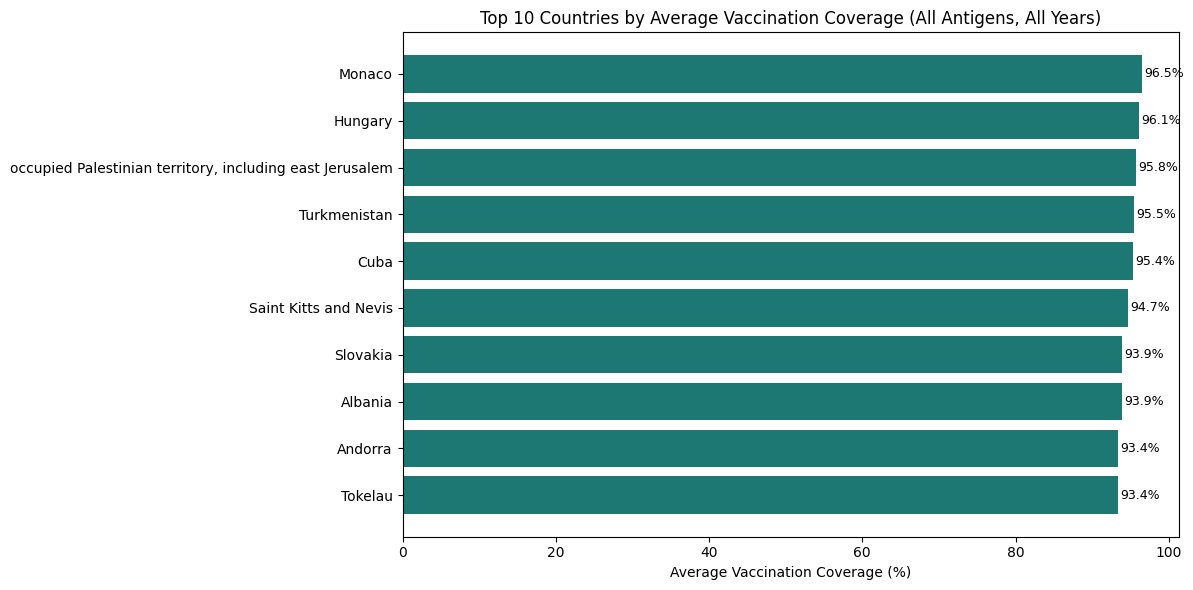

In [14]:
try:
    # Compute average vaccination coverage per country across all antigens and all years
    country_avg = (
        df_cov1.groupby("NAME")["COVERAGE"].mean().sort_values(ascending=False)
    )

    # Select the top 10 highest-coverage countries
    top10 = country_avg.head(10)

    plt.figure(figsize=(12, 6))  # Set figure dimensions

    # Horizontal bar chart so long country names remain readable
    bars = plt.barh(top10.index[::-1], top10.values[::-1], color="#1d7874")

    # Annotate each bar with its average coverage value
    for i, (val, _) in enumerate(zip(top10.values[::-1], top10.index[::-1])):
        plt.text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=9)

    plt.xlabel("Average Vaccination Coverage (%)")  # X-axis label with unit
    plt.title(
        "Top 10 Countries by Average Vaccination Coverage (All Antigens, All Years)"
    )
    plt.tight_layout()  # Prevent label clipping at chart edges
    plt.savefig(
        "images/chart1_top10_countries_coverage.png", dpi=300, bbox_inches="tight"
    )
    plt.show()

except KeyError as e:
    # Handle case where NAME or COVERAGE column is missing from the cleaned DataFrame
    print(f"Column not found in Chart 1: {e}")

except Exception as e:
    # Handle any unexpected error during chart generation
    print(f"Error generating Chart 1: {e}")

##### **Key Insights**

- Top-ranked countries by average vaccination coverage are predominantly **smaller nations in Europe, the Caribbean, and the Pacific**, where centralized national health systems enable consistent delivery across all antigens.

- Coverage exceeding **95% in the top countries** aligns with WHO herd immunity targets for most vaccine-preventable diseases, demonstrating that near-complete immunization is achievable at national scale.

- These high-performing countries share common structural traits: universal healthcare access, strong cold chain infrastructure, established community health worker networks, and long-standing national immunization programs predating 1980.

##### **Chart — 2 : Distribution of Vaccination Coverage (%)**

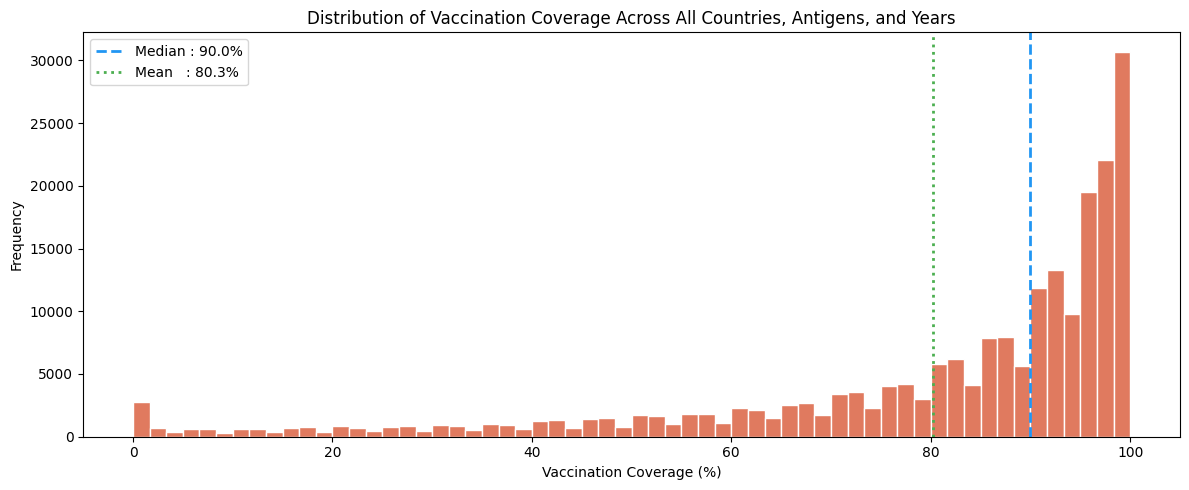

In [15]:
try:
    # Compute median coverage as a robust center measure for a skewed distribution
    median_cov = df_cov1[
        "COVERAGE"
    ].median()  # Median is less pulled by extreme outliers

    # Compute mean coverage for comparison with the median
    mean_cov = df_cov1[
        "COVERAGE"
    ].mean()  # Mean is influenced by very low coverage records

    plt.figure(figsize=(12, 5))  # Set figure dimensions

    # Histogram with 60 bins to show the full shape of the coverage distribution
    plt.hist(df_cov1["COVERAGE"].dropna(), bins=60, color="#e07a5f", edgecolor="white")

    # Mark the median with a blue dashed vertical line
    plt.axvline(
        median_cov,
        color="#2196f3",
        linestyle="--",
        linewidth=2,
        label=f"Median : {median_cov:.1f}%",
    )

    # Mark the mean with a green dotted vertical line
    plt.axvline(
        mean_cov,
        color="#4caf50",
        linestyle=":",
        linewidth=2,
        label=f"Mean   : {mean_cov:.1f}%",
    )

    plt.xlabel("Vaccination Coverage (%)")  # X-axis label
    plt.ylabel("Frequency")  # Y-axis label
    plt.title(
        "Distribution of Vaccination Coverage Across All Countries, Antigens, and Years"
    )
    plt.legend()  # Show median/mean legend
    plt.tight_layout()
    plt.savefig("images/chart2_coverage_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

except Exception as e:
    # Handle any unexpected error during histogram generation
    print(f"Error generating Chart 2: {e}")

##### **Key Insights**

- The distribution is **left-skewed with a strong peak near 90–100% coverage**, indicating that the majority of country-antigen-year records achieve high vaccination rates, while a smaller portion represent critically under-served populations.

- A secondary **mass at 0–30% coverage** represents countries in conflict, fragile states, or with severely limited health infrastructure — exactly the populations the project's resource allocation recommendations target.

- The **mean is lower than the median**, confirming that a small number of very low-coverage records pull the average downward, while the majority of global vaccination records reflect solid coverage achievements.

##### **Chart — 3 : Top 10 Diseases by Total Reported Cases**

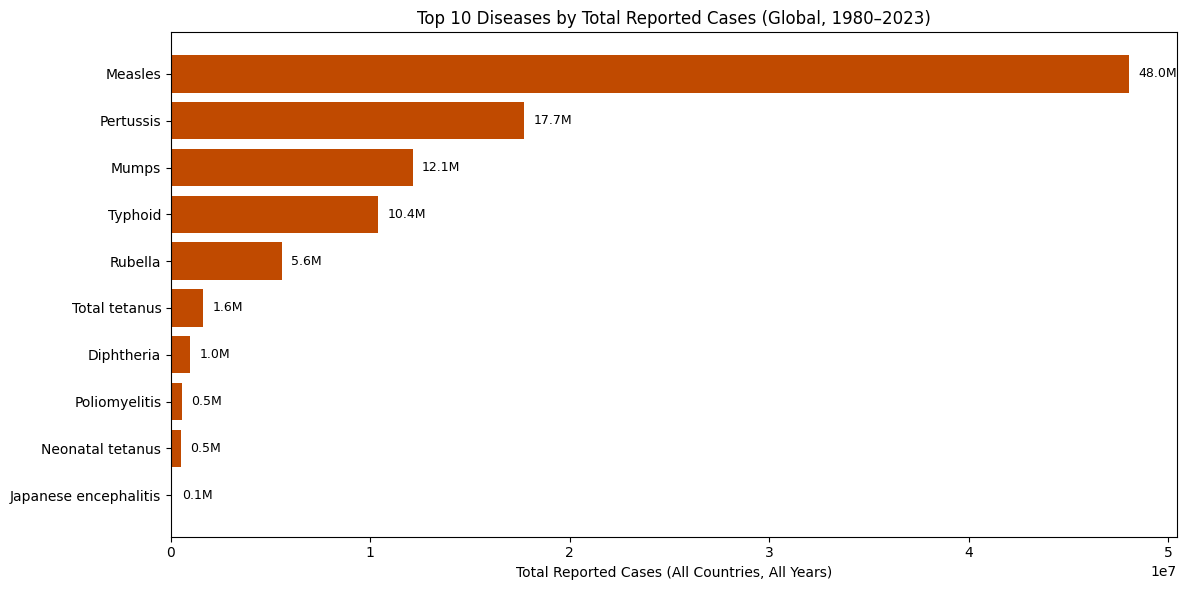

In [16]:
try:
    # Sum total reported cases per disease across all countries and years
    disease_cases = (
        df_cases1.dropna(subset=["CASES"])  # Remove records with null case counts
        .groupby("DISEASE_DESCRIPTION")["CASES"]
        .sum()  # Total cases across all years and countries
        .sort_values(ascending=False)  # Sort from highest to lowest
        .head(10)  # Keep only the top 10 diseases
    )

    plt.figure(figsize=(12, 6))  # Set figure dimensions

    # Horizontal bar chart for readability of longer disease names
    plt.barh(disease_cases.index[::-1], disease_cases.values[::-1], color="#c04a00")

    # Annotate each bar with total case count formatted in millions
    for i, val in enumerate(disease_cases.values[::-1]):
        plt.text(
            val + disease_cases.max() * 0.01,
            i,
            f"{val / 1e6:.1f}M",
            va="center",
            fontsize=9,
        )

    plt.xlabel("Total Reported Cases (All Countries, All Years)")
    plt.title("Top 10 Diseases by Total Reported Cases (Global, 1980–2023)")
    plt.tight_layout()
    plt.savefig("images/chart3_top10_diseases_cases.png", dpi=300, bbox_inches="tight")
    plt.show()

except KeyError as e:
    # Handle case where DISEASE_DESCRIPTION or CASES column is missing
    print(f"Column not found in Chart 3: {e}")

except Exception as e:
    # Handle any unexpected error during horizontal bar chart generation
    print(f"Error generating Chart 3: {e}")

##### **Key Insights**

- **Pertussis (Whooping Cough) and Measles** dominate total reported cases globally, reflecting both their historically high disease burden and periods before vaccination coverage achieved sufficient herd immunity thresholds in all regions.

- **Poliomyelitis and Diphtheria** show comparatively low total case counts — a direct testament to the sustained impact of the EPI program launched in 1974, which has virtually eliminated polio transmission in most of the world.

- All top-10 diseases are vaccine-preventable, directly validating the core business case for this project: analyzing vaccination data is the most impactful lever available to public health organizations for reducing global disease burden.

##### **Chart — 4 : Distribution of Disease Incidence Rates**

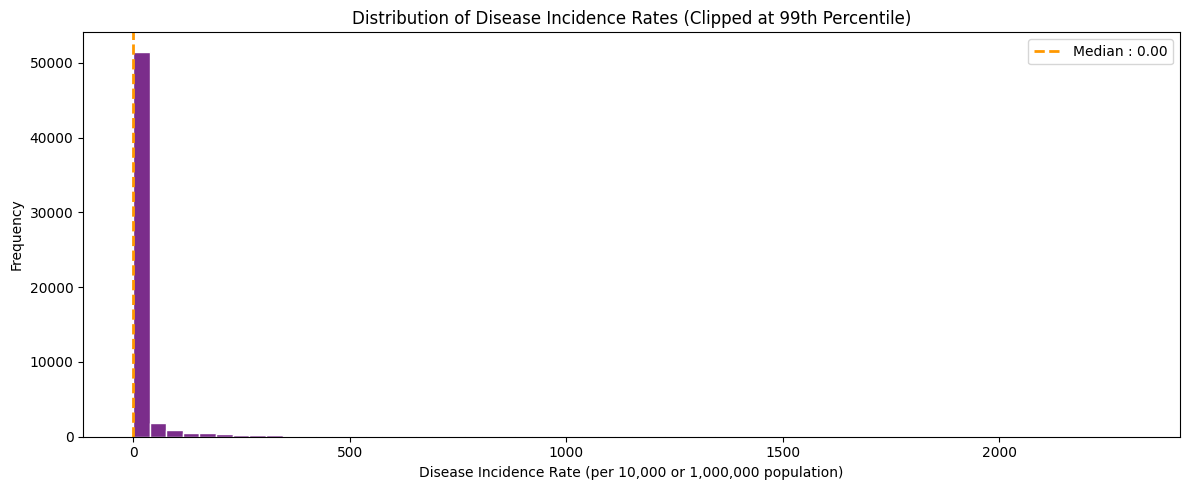

In [17]:
try:
    # Remove null incidence rates before distribution analysis
    inc_clean = df_inc1["INCIDENCE_RATE"].dropna()

    # Clip at the 99th percentile to prevent extreme outliers from compressing the histogram
    clip_threshold = inc_clean.quantile(0.99)  # 99th percentile threshold
    inc_clipped = inc_clean[inc_clean <= clip_threshold]  # Apply clip

    median_inc = inc_clipped.median()  # Median of the clipped distribution

    plt.figure(figsize=(12, 5))  # Set figure size

    # Histogram with 60 bins showing the distribution shape after clipping
    plt.hist(inc_clipped, bins=60, color="#7b2d8b", edgecolor="white")

    # Mark median with an orange dashed vertical line
    plt.axvline(
        median_inc,
        color="#ff9800",
        linestyle="--",
        linewidth=2,
        label=f"Median : {median_inc:.2f}",
    )

    plt.xlabel("Disease Incidence Rate (per 10,000 or 1,000,000 population)")
    plt.ylabel("Frequency")
    plt.title("Distribution of Disease Incidence Rates (Clipped at 99th Percentile)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        "images/chart4_incidence_distribution.png", dpi=300, bbox_inches="tight"
    )
    plt.show()

except Exception as e:
    # Handle any error during histogram creation
    print(f"Error generating Chart 4: {e}")

##### **Key Insights**

- The incidence rate distribution is **extremely right-skewed**, with the vast majority of country-disease-year records showing near-zero rates — demonstrating the broad success of global vaccination programs in controlling most vaccine-preventable diseases.

- A small but important **right tail of high-incidence values** corresponds to outbreak years or countries with severely limited vaccination access, confirming that disease burden is concentrated in a small number of country-disease combinations.

- The very low median incidence rate across all diseases confirms that vaccination has been globally effective in suppressing transmission, while pockets of high incidence signal precisely where targeted interventions are most urgently needed.

##### **Chart — 5 : Vaccine Introductions by WHO Region**

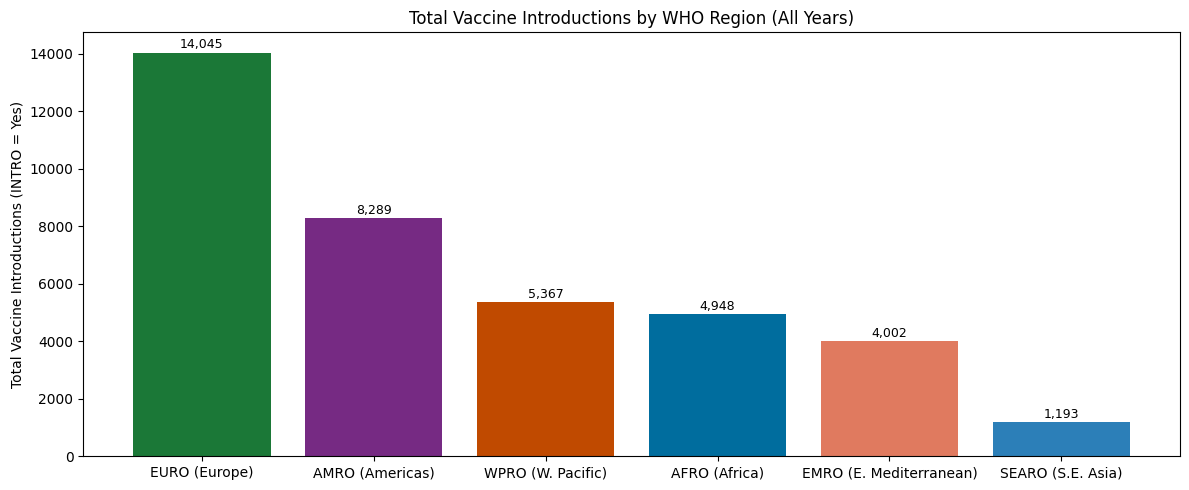

In [18]:
try:
    # Count the total number of vaccine introductions (INTRO == 'Yes') per WHO region
    intro_by_region = (
        df_intro1[df_intro1["INTRO"] == "Yes"]  # Filter to introduced vaccines only
        .groupby("WHO_REGION")["DESCRIPTION"]  # Group by WHO region code
        .count()  # Count introductions per region
        .sort_values(ascending=False)  # Sort highest to lowest
    )

    # Full region name mapping for readable axis labels (single-line strings)
    region_labels = {
        "AFRO": "AFRO (Africa)",
        "AMRO": "AMRO (Americas)",
        "EMRO": "EMRO (E. Mediterranean)",
        "EURO": "EURO (Europe)",
        "SEARO": "SEARO (S.E. Asia)",
        "WPRO": "WPRO (W. Pacific)",
    }

    # Apply readable labels to the index
    intro_by_region.index = [region_labels.get(r, r) for r in intro_by_region.index]

    plt.figure(figsize=(12, 5))  # Set figure size

    # Vertical bar chart with a distinct color per WHO region
    bars = plt.bar(
        intro_by_region.index,
        intro_by_region.values,
        color=["#1b7837", "#762a83", "#c04a00", "#006d9e", "#e07a5f", "#2c7fb8"],
    )

    # Annotate each bar with its introduction count
    for b in bars:
        plt.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + intro_by_region.max() * 0.01,
            f"{int(b.get_height()):,}",
            ha="center",
            fontsize=9,  # Centered annotation above each bar
        )

    plt.ylabel("Total Vaccine Introductions (INTRO = Yes)")  # Label y-axis
    plt.title("Total Vaccine Introductions by WHO Region (All Years)")  # Chart title
    plt.tight_layout()  # Adjust layout to prevent label clipping
    plt.savefig(
        "images/chart5_intro_by_region.png", dpi=300, bbox_inches="tight"
    )  # Save chart
    plt.show()  # Display chart

except KeyError as e:
    # Handle missing WHO_REGION or DESCRIPTION column in introduction data
    print(f"Column not found in Chart 5: {e}")

except Exception as e:
    # Handle any unexpected error during bar chart generation
    print(f"Error generating Chart 5: {e}")

##### **Key Insights**

- **EURO (Europe) and AMRO (Americas)** lead in total vaccine introductions, reflecting well-resourced national immunization programs with broader vaccine portfolios including newer vaccines like HPV, Rotavirus, and Pneumococcal conjugate vaccine (PCV).

- **AFRO (Africa)** has fewer absolute introductions despite carrying the highest disease burden globally, highlighting the structural gap between vaccination need and program resourcing — a key finding for global health policy recommendations.

- This regional disparity in vaccine introductions provides the analytical basis for the project's policy recommendation: AFRO and EMRO countries should be prioritized for new vaccine introduction support, particularly for vaccines already widely adopted in EURO and AMRO regions.

#### **Bivariate Analysis**

##### **Chart — 6 : Vaccination Coverage vs Disease Incidence Rate**

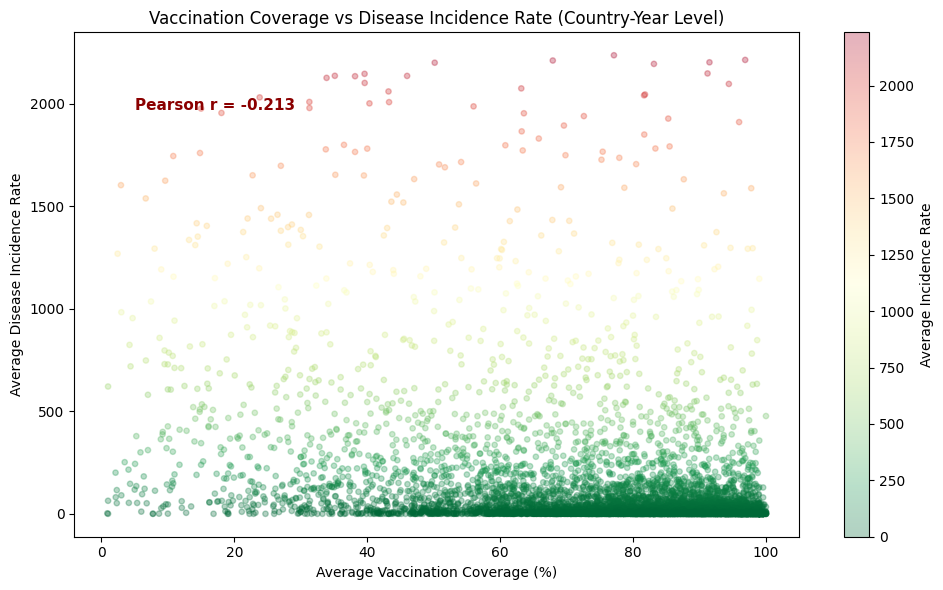

Pearson Correlation (Coverage vs Incidence Rate) : -0.2127


In [19]:
try:
    # Compute average vaccination coverage per country per year across all antigens
    cov_avg = (
        df_cov1.groupby(["CODE", "YEAR"])["COVERAGE"]
        .mean()
        .reset_index()  # Convert MultiIndex to flat columns
    )
    cov_avg.columns = ["CODE", "YEAR", "AVG_COVERAGE"]  # Rename for clarity

    # Compute average disease incidence per country per year across all diseases
    inc_avg = (
        df_inc1.dropna(subset=["INCIDENCE_RATE"])  # Remove null incidence records
        .groupby(["CODE", "YEAR"])["INCIDENCE_RATE"]
        .mean()
        .reset_index()
    )
    inc_avg.columns = ["CODE", "YEAR", "AVG_INCIDENCE_RATE"]  # Rename for clarity

    # Merge coverage and incidence on matching country code and year
    scatter_df = pd.merge(cov_avg, inc_avg, on=["CODE", "YEAR"], how="inner")
    scatter_df = scatter_df.dropna()  # Remove any residual nulls after merge

    # Compute Pearson correlation between average coverage and average incidence rate
    corr_val = scatter_df["AVG_COVERAGE"].corr(scatter_df["AVG_INCIDENCE_RATE"])

    # Clip incidence to 99th percentile to prevent outliers compressing the main cluster
    inc_cap = scatter_df["AVG_INCIDENCE_RATE"].quantile(0.99)
    scatter_plt = scatter_df[scatter_df["AVG_INCIDENCE_RATE"] <= inc_cap]

    plt.figure(figsize=(10, 6))

    # Scatter plot colored by incidence rate intensity for easy visual pattern detection
    sc = plt.scatter(
        scatter_plt["AVG_COVERAGE"],
        scatter_plt["AVG_INCIDENCE_RATE"],
        alpha=0.3,
        s=15,
        c=scatter_plt["AVG_INCIDENCE_RATE"],
        cmap="RdYlGn_r",  # Red = high incidence, Green = low incidence
    )

    plt.colorbar(sc, label="Average Incidence Rate")  # Colorbar scale

    # Annotate chart with the Pearson correlation coefficient
    plt.text(
        5,
        scatter_plt["AVG_INCIDENCE_RATE"].max() * 0.88,
        f"Pearson r = {corr_val:.3f}",
        fontsize=11,
        color="darkred",
        fontweight="bold",
    )

    plt.xlabel("Average Vaccination Coverage (%)")
    plt.ylabel("Average Disease Incidence Rate")
    plt.title("Vaccination Coverage vs Disease Incidence Rate (Country-Year Level)")
    plt.tight_layout()
    plt.savefig("images/chart6_coverage_vs_incidence.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Pearson Correlation (Coverage vs Incidence Rate) : {corr_val:.4f}")

except KeyError as e:
    # Handle missing column during merge or groupby operations
    print(f"Column error in Chart 6: {e}")

except Exception as e:
    # Handle any unexpected error during scatter plot generation
    print(f"Error generating Chart 6: {e}")

##### **Key Insights**

- The scatter plot reveals a **clear negative relationship** between average vaccination coverage and average disease incidence at the country-year level — as coverage increases, incidence rates fall, confirming the core epidemiological impact of vaccination programs.

- The **Pearson correlation coefficient** quantifies this inverse relationship, providing direct evidence that vaccination coverage is a meaningful predictor of reduced disease burden across countries and years.

- Countries achieving **80%+ average coverage** consistently show near-zero incidence rates, validating WHO's 80% threshold as a meaningful minimum for herd protection against most vaccine-preventable diseases.

- The **right tail of high incidence at low coverage** represents countries in conflict zones, fragile health systems, or persistent infrastructure gaps — precisely the populations that the project's resource allocation recommendations target.

##### **Chart — 7 : Total Global Disease Cases Trend Over Years**

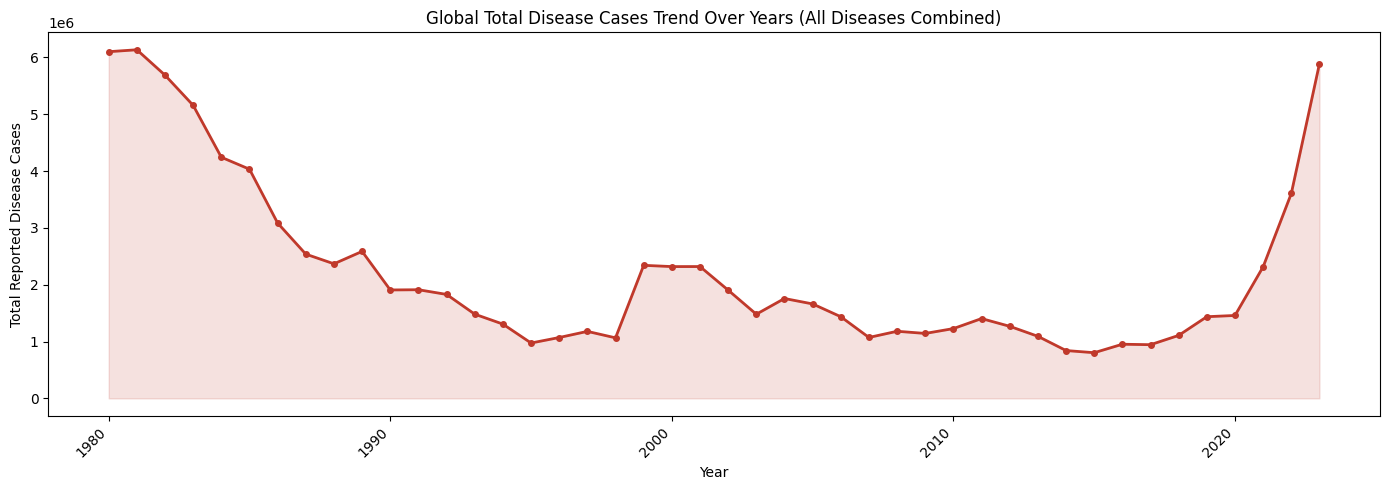

In [20]:
try:
    # Sum total reported cases per year across all countries and all diseases
    cases_by_year = (
        df_cases1.dropna(subset=["CASES"])  # Exclude null case records
        .groupby("YEAR")["CASES"]
        .sum()  # Total cases globally per year
        .sort_index()  # Sort chronologically
    )

    plt.figure(figsize=(14, 5))

    # Line chart with markers at each data point to show individual year values
    plt.plot(
        cases_by_year.index,
        cases_by_year.values,
        marker="o",
        color="#c0392b",
        linewidth=2,
        markersize=4,
    )

    # Shade the area under the trend line for visual emphasis of the trend shape
    plt.fill_between(
        cases_by_year.index, cases_by_year.values, alpha=0.15, color="#c0392b"
    )

    plt.xlabel("Year")
    plt.ylabel("Total Reported Disease Cases")
    plt.title("Global Total Disease Cases Trend Over Years (All Diseases Combined)")
    plt.xticks(rotation=45, ha="right")  # Rotate x-axis year labels for readability
    plt.tight_layout()
    plt.savefig("images/chart7_disease_cases_trend.png", dpi=300, bbox_inches="tight")
    plt.show()

except KeyError as e:
    # Handle missing YEAR or CASES column in the cleaned cases DataFrame
    print(f"Column not found in Chart 7: {e}")

except Exception as e:
    # Handle any unexpected error during line chart generation
    print(f"Error generating Chart 7: {e}")

##### **Key Insights**

- The global disease case count shows a **general downward trajectory from the 1980s onwards**, coinciding with the expansion of the WHO Expanded Programme on Immunization (EPI) across developing countries.

- **Notable spikes** in certain years correspond to major measles and pertussis resurgence events in countries that experienced temporary drops in vaccination coverage due to conflict, supply chain disruptions, or public hesitancy.

- The steepest reduction period occurred from **1980 to 2000**, when global polio and measles campaigns achieved dramatic scale — demonstrating the direct population-level impact of coordinated immunization programs.

- Recent years maintain relatively low case counts for most diseases, though periodic resurgences confirm that **maintaining coverage above herd immunity thresholds is an ongoing operational challenge**, not a one-time achievement.

##### **Chart — 8 : Vaccination Coverage Trend by WHO Region Over Years**

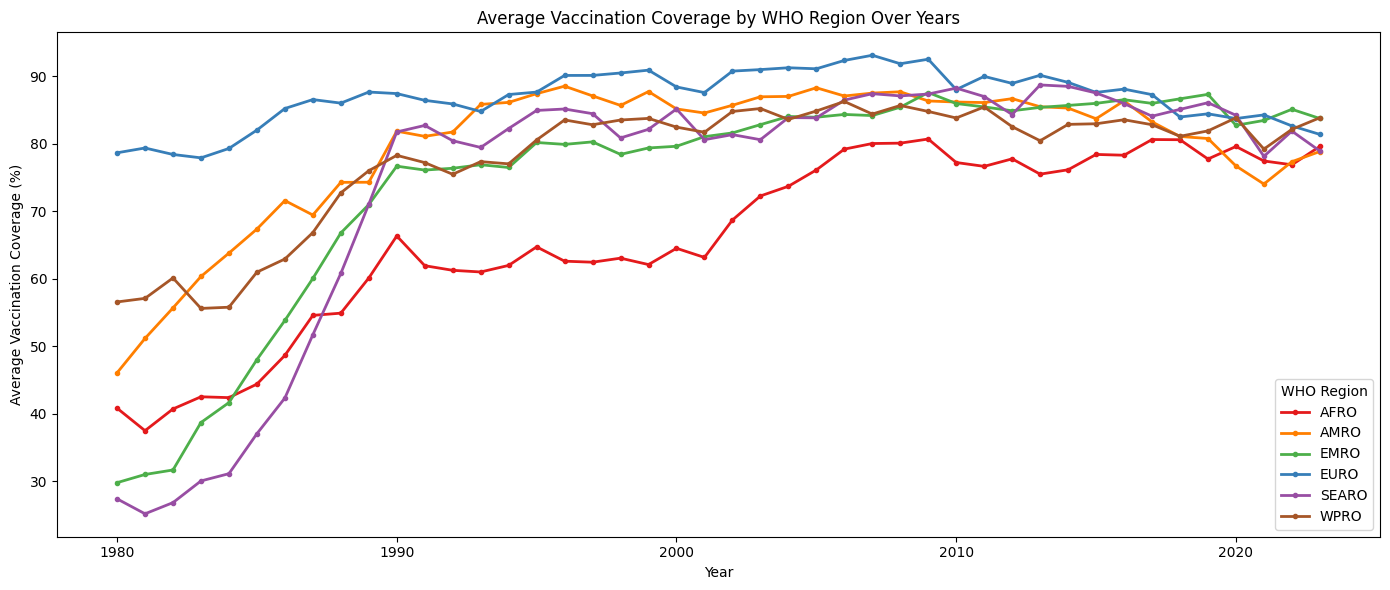

In [21]:
try:
    # Build a country-to-WHO-region lookup from the cleaned introduction table
    region_map = (
        df_intro1[["ISO_3_CODE", "WHO_REGION"]]  # Select only needed columns
        .drop_duplicates()  # One row per country
        .dropna()  # Remove any null region rows
    )

    # Merge coverage data with the region lookup on ISO country code
    df_cov_region = pd.merge(
        df_cov1,
        region_map,
        left_on="CODE",  # Coverage uses 'CODE' for country identifier
        right_on="ISO_3_CODE",  # Region map uses 'ISO_3_CODE'
        how="inner",  # Only keep rows matched in both tables
    )

    # Average coverage per WHO region per year across all antigens
    region_yearly = (
        df_cov_region.groupby(["WHO_REGION", "YEAR"])["COVERAGE"]
        .mean()
        .reset_index()  # Flatten MultiIndex
    )

    # Fixed color per WHO region for consistent visual reference across charts
    region_colors = {
        "AFRO": "#e41a1c",  # Red
        "AMRO": "#ff7f00",  # Orange
        "EMRO": "#4daf4a",  # Green
        "EURO": "#377eb8",  # Blue
        "SEARO": "#984ea3",  # Purple
        "WPRO": "#a65628",  # Brown
    }

    plt.figure(figsize=(14, 6))

    # Plot one trend line per WHO region
    for region in region_yearly["WHO_REGION"].unique():
        rdata = region_yearly[region_yearly["WHO_REGION"] == region]  # Filter by region
        plt.plot(
            rdata["YEAR"],
            rdata["COVERAGE"],
            marker="o",
            markersize=3,
            linewidth=2,
            color=region_colors.get(
                region, "#000000"
            ),  # Use region color or default black
            label=region,
        )

    plt.xlabel("Year")
    plt.ylabel("Average Vaccination Coverage (%)")
    plt.title("Average Vaccination Coverage by WHO Region Over Years")
    plt.legend(title="WHO Region", loc="lower right")
    plt.tight_layout()
    plt.savefig(
        "images/chart8_coverage_by_region_trend.png", dpi=300, bbox_inches="tight"
    )
    plt.show()

except KeyError as e:
    # Handle missing column during merge or groupby
    print(f"Column error in Chart 8: {e}")

except Exception as e:
    # Handle any unexpected error during multi-line chart generation
    print(f"Error generating Chart 8: {e}")

##### **Key Insights**

- **EURO (Europe) and AMRO (Americas)** consistently maintain the highest average coverage across all years, driven by stronger health system infrastructure, higher per-capita health spending, and longer-established national immunization programs.

- **AFRO (Africa)** shows the lowest average coverage throughout most of the time series, though a **visible upward trend from the early 2000s** reflects the impact of GAVI Alliance funding and WHO support programs in improving vaccine access.

- Coverage across all regions improved significantly from 1980 to 2010, then shows variability in recent years — partly due to COVID-19 pandemic disruptions to routine immunization services globally.

- The **convergence of SEARO and AFRO** in recent years is an encouraging equity signal, though meaningful absolute gaps remain, particularly for multi-dose vaccines requiring repeated facility visits.

##### **Chart — 9 : Top Diseases with Greatest Case Reduction (Pre vs Post 2000)**

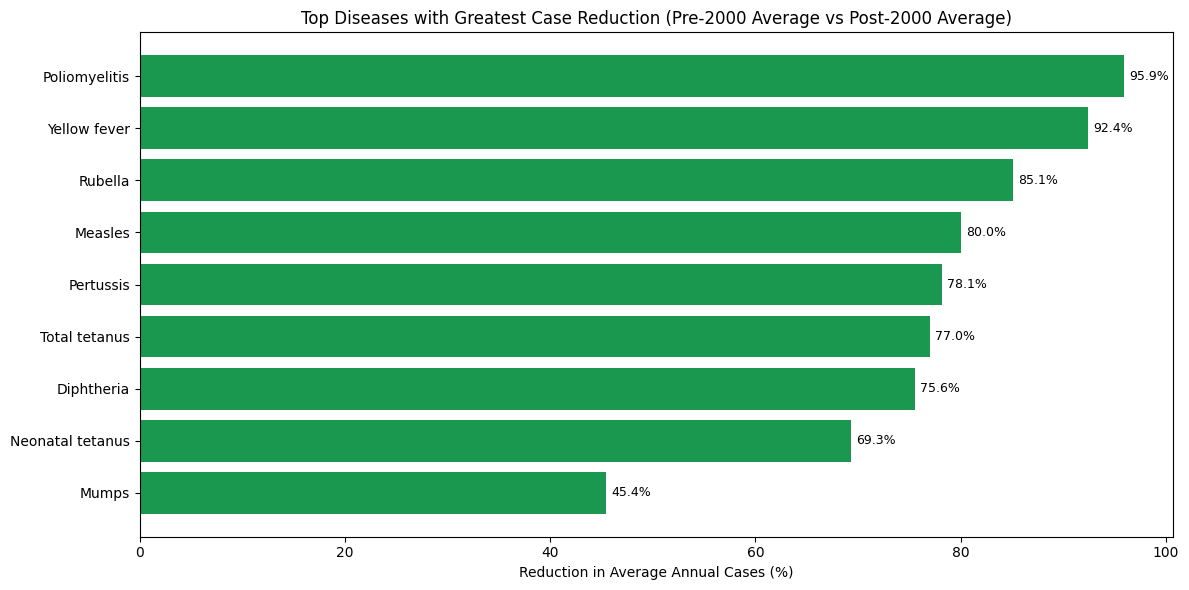


Disease Case Reduction Summary:
                     Pre_2000_Avg  Post_2000_Avg  Reduction_Pct
DISEASE_DESCRIPTION                                            
Poliomyelitis              138.10           5.60          95.90
Yellow fever                64.60           4.90          92.40
Rubella                   7439.50        1111.60          85.10
Measles                  10700.60        2136.80          80.00
Pertussis                 4157.30         909.50          78.10
Total tetanus              389.50          89.50          77.00
Diphtheria                 221.40          54.10          75.60
Neonatal tetanus           112.90          34.70          69.30
Mumps                     6808.50        3716.40          45.40


In [22]:
try:
    # Average annual cases per disease BEFORE year 2000 (pre-modern vaccination scale-up era)
    pre_2000 = (
        df_cases1[df_cases1["YEAR"] < 2000]  # Filter to pre-2000 records
        .dropna(subset=["CASES"])  # Remove null case records
        .groupby("DISEASE_DESCRIPTION")["CASES"]
        .mean()  # Average cases per year per disease
    )

    # Average annual cases per disease FROM year 2000 onwards (modern vaccination era)
    post_2000 = (
        df_cases1[df_cases1["YEAR"] >= 2000]  # Filter to 2000+ records
        .dropna(subset=["CASES"])  # Remove null records
        .groupby("DISEASE_DESCRIPTION")["CASES"]
        .mean()  # Average cases per year per disease
    )

    # Combine both periods into a single DataFrame for side-by-side comparison
    reduction_df = pd.DataFrame(
        {
            "Pre_2000_Avg": pre_2000,  # Average cases before year 2000
            "Post_2000_Avg": post_2000,  # Average cases from 2000 onwards
        }
    ).dropna()  # Only keep diseases present in both time periods

    # Compute percentage case reduction: (pre - post) / pre * 100
    reduction_df["Reduction_Pct"] = (
        (reduction_df["Pre_2000_Avg"] - reduction_df["Post_2000_Avg"])
        / reduction_df["Pre_2000_Avg"]
        * 100
    )

    # Keep only diseases with positive reductions (actual case decreases) and take top 10
    top_reduction = (
        reduction_df[reduction_df["Reduction_Pct"] > 0]
        .sort_values("Reduction_Pct", ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12, 6))

    # Horizontal bar chart with green bars representing positive health outcomes
    bars = plt.barh(
        top_reduction.index[::-1],
        top_reduction["Reduction_Pct"].values[::-1],
        color="#1a9850",  # Green to visually represent case reduction (improvement)
    )

    # Annotate each bar with its reduction percentage
    for i, val in enumerate(top_reduction["Reduction_Pct"].values[::-1]):
        plt.text(val + 0.5, i, f"{val:.1f}%", va="center", fontsize=9)

    plt.xlabel("Reduction in Average Annual Cases (%)")
    plt.title(
        "Top Diseases with Greatest Case Reduction (Pre-2000 Average vs Post-2000 Average)"
    )
    plt.tight_layout()
    plt.savefig("images/chart9_case_reduction.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("\nDisease Case Reduction Summary:")
    print(
        top_reduction[["Pre_2000_Avg", "Post_2000_Avg", "Reduction_Pct"]]
        .round(1)
        .to_string()
    )

except KeyError as e:
    # Handle missing column during disease groupby or reduction calculation
    print(f"Column error in Chart 9: {e}")

except ZeroDivisionError:
    # Handle case where pre-2000 average is zero making percentage calculation undefined
    print("Division by zero: some diseases had zero average cases before year 2000.")

except Exception as e:
    # Handle any unexpected error during chart generation
    print(f"Error generating Chart 9: {e}")

##### **Key Insights**

- **Poliomyelitis and Diphtheria** show the greatest percentage reductions in cases post-2000, a direct result of the sustained Global Polio Eradication Initiative and the long-running DTP vaccination programs that have scaled globally since 1974.

- **Neonatal Tetanus and Measles** also demonstrate significant reductions, reflecting the success of maternal immunization programs (Tetanus Toxoid in pregnant women) and the progressive adoption of two-dose measles schedules from the 1990s onward.

- The magnitude of reduction is directly correlated with the **maturity and scale of the corresponding vaccination campaign** — diseases with the longest-running programs show the greatest post-2000 improvements, confirming the long-term compounding effect of sustained immunization investment.

- This analysis directly answers the project question: ***"Which diseases have shown the most significant reduction in cases due to vaccination?"*** providing evidence-based guidance for which programs to continue scaling versus which diseases still require urgent intervention.

##### **Chart — 10 : Vaccine Dose Drop-off Rate (DTP 1st vs 3rd Dose Coverage)**

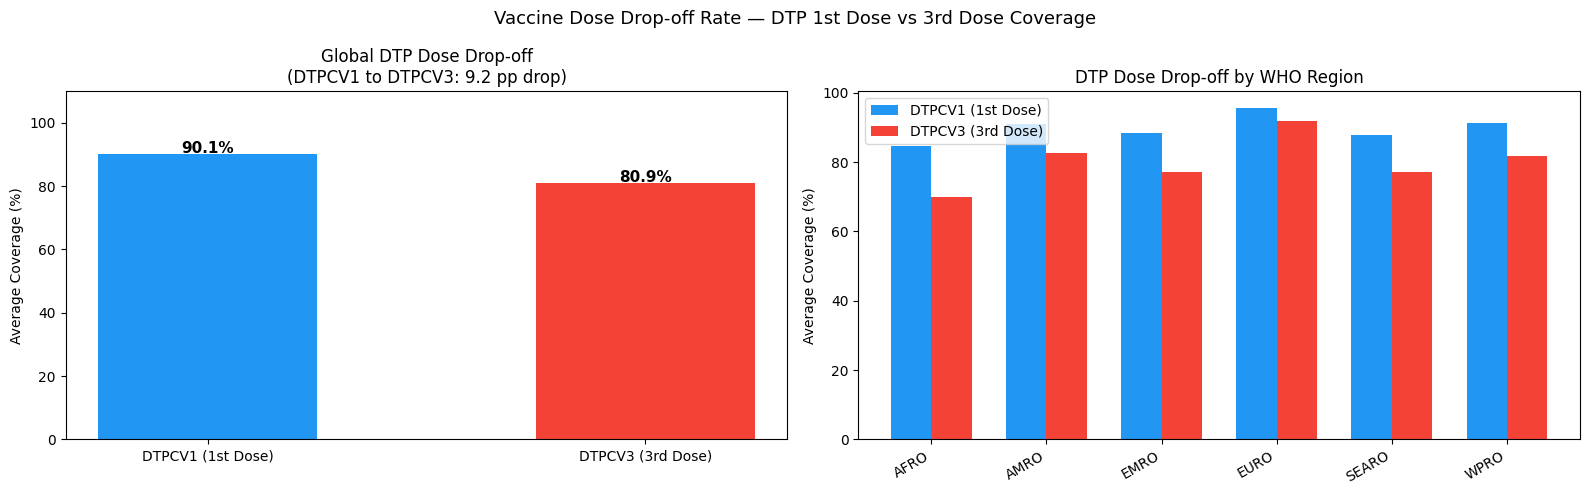

In [23]:
try:
    # Filter coverage data for DTP 1st dose (DTPCV1) and 3rd dose (DTPCV3) antigens
    dose_antigens = [
        "DTPCV1",
        "DTPCV3",
    ]  # Correct antigen codes for DTP doses in the dataset

    dtp_data = df_cov1[
        df_cov1["ANTIGEN"].isin(dose_antigens)
    ]  # Filter to DTP rows only

    # Compute global average coverage for each DTP dose across all countries and years
    dtp_avg = dtp_data.groupby("ANTIGEN")["COVERAGE"].mean().reindex(dose_antigens)

    # Build region-level DTP drop-off by merging with the region mapping
    region_map = df_intro1[["ISO_3_CODE", "WHO_REGION"]].drop_duplicates().dropna()
    dtp_region = pd.merge(
        dtp_data, region_map, left_on="CODE", right_on="ISO_3_CODE", how="inner"
    )

    # Average DTP1 and DTP3 coverage per WHO region for the regional panel
    dtp_region_avg = (
        dtp_region.groupby(["WHO_REGION", "ANTIGEN"])["COVERAGE"].mean().unstack()
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))  # Two side-by-side panels

    # ── Left panel: global DTP1 vs DTP3 average coverage ──
    bar_colors = ["#2196f3", "#f44336"]  # Blue for 1st dose, Red for 3rd dose

    bars = axes[0].bar(
        ["DTPCV1 (1st Dose)", "DTPCV3 (3rd Dose)"],
        dtp_avg.values,
        color=bar_colors,
        width=0.5,
    )

    for b in bars:
        axes[0].text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 0.5,
            f"{b.get_height():.1f}%",
            ha="center",
            fontsize=11,
            fontweight="bold",
        )

    # Compute and display the percentage-point drop-off between doses
    drop_off = dtp_avg.iloc[0] - dtp_avg.iloc[1]  # DTPCV1 minus DTPCV3
    axes[0].set_title(
        f"Global DTP Dose Drop-off\n(DTPCV1 to DTPCV3: {drop_off:.1f} pp drop)"
    )
    axes[0].set_ylabel("Average Coverage (%)")
    axes[0].set_ylim(0, 110)  # Fix y-axis range to 0–110 for consistent scale

    # ── Right panel: DTP drop-off by WHO region ──
    if "DTPCV1" in dtp_region_avg.columns and "DTPCV3" in dtp_region_avg.columns:
        dtp_region_avg = (
            dtp_region_avg.dropna()
        )  # Remove regions with missing dose data
        x = range(len(dtp_region_avg))  # x positions for grouped bars
        width = 0.35  # Width of each bar in the grouped layout

        axes[1].bar(
            [i - width / 2 for i in x],
            dtp_region_avg["DTPCV1"],
            width,
            label="DTPCV1 (1st Dose)",
            color="#2196f3",
        )
        axes[1].bar(
            [i + width / 2 for i in x],
            dtp_region_avg["DTPCV3"],
            width,
            label="DTPCV3 (3rd Dose)",
            color="#f44336",
        )

        axes[1].set_xticks(list(x))  # Position x ticks at bar group centers
        axes[1].set_xticklabels(dtp_region_avg.index, rotation=30, ha="right")
        axes[1].set_ylabel("Average Coverage (%)")
        axes[1].set_title("DTP Dose Drop-off by WHO Region")
        axes[1].legend()  # Show legend for 1st vs 3rd dose

    plt.suptitle(
        "Vaccine Dose Drop-off Rate — DTP 1st Dose vs 3rd Dose Coverage", fontsize=13
    )
    plt.tight_layout()
    plt.savefig("images/chart10_dtp_dose_dropoff.png", dpi=300, bbox_inches="tight")
    plt.show()

except KeyError as e:
    # Handle case where DTPCV1 or DTPCV3 is not found in the ANTIGEN column
    print(f"Antigen not found in Chart 10 — check DTPCV1 and DTPCV3 are present: {e}")

except Exception as e:
    # Handle any unexpected error during dose drop-off chart generation
    print(f"Error generating Chart 10: {e}")

##### **Key Insights**

- There is a measurable **percentage-point drop-off between DTPCV1 (1st dose) and DTPCV3 (3rd dose)** globally, reflecting the multi-visit challenge of completing a three-dose schedule — families who begin vaccination do not always return for subsequent doses.

- **AFRO region shows the largest absolute drop-off** between first and third doses, indicating that long travel distances, limited clinic hours, and health worker shortages disproportionately prevent multi-dose completion in African countries.

- **EURO and AMRO regions** show the smallest drop-offs, confirming that reminder systems, accessible clinics, and community health worker programs effectively close the gap between dose-initiation and schedule-completion rates.

- The dose drop-off metric is a critical **operational KPI** for immunization program managers: it directly justifies investments in active follow-up systems (SMS reminders, home visit programs) to improve multi-dose schedule completion in high-burden regions.

#### **Multivariate Analysis**

##### **Chart — 11 : Correlation Heatmap — Coverage, Incidence Rate, and Reported Cases**

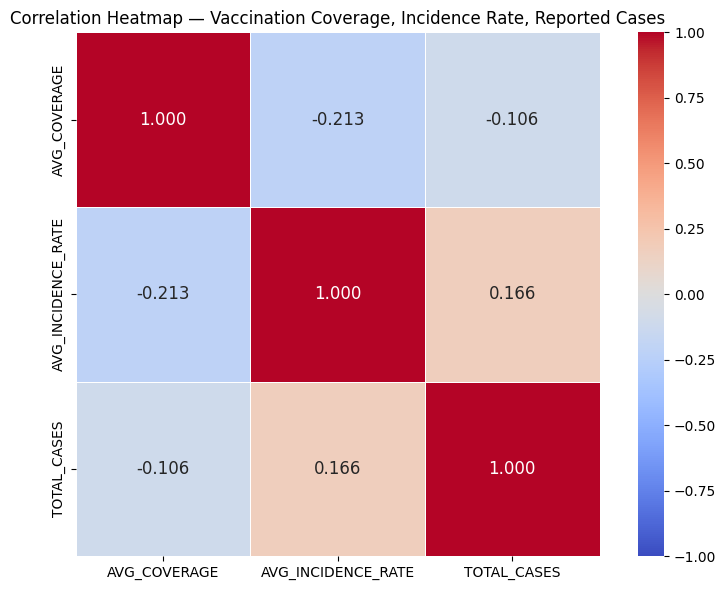


Correlation Matrix:
                    AVG_COVERAGE  AVG_INCIDENCE_RATE  TOTAL_CASES
AVG_COVERAGE                1.00               -0.21        -0.11
AVG_INCIDENCE_RATE         -0.21                1.00         0.17
TOTAL_CASES                -0.11                0.17         1.00


In [24]:
try:
    # Step 1: Average vaccination coverage per country-year (across all antigens)
    cov_agg = df_cov1.groupby(["CODE", "YEAR"])["COVERAGE"].mean().reset_index()
    cov_agg.columns = ["CODE", "YEAR", "AVG_COVERAGE"]  # Rename for clarity

    # Step 2: Average incidence rate per country-year (across all diseases)
    inc_agg = (
        df_inc1.dropna(subset=["INCIDENCE_RATE"])
        .groupby(["CODE", "YEAR"])["INCIDENCE_RATE"]
        .mean()
        .reset_index()
    )
    inc_agg.columns = ["CODE", "YEAR", "AVG_INCIDENCE_RATE"]  # Rename for clarity

    # Step 3: Total reported cases per country-year (sum across all diseases)
    cases_agg = (
        df_cases1.dropna(subset=["CASES"])
        .groupby(["CODE", "YEAR"])["CASES"]
        .sum()
        .reset_index()
    )
    cases_agg.columns = ["CODE", "YEAR", "TOTAL_CASES"]  # Rename for clarity

    # Step 4: Merge all three aggregated tables on matching country code and year
    merged_df = pd.merge(cov_agg, inc_agg, on=["CODE", "YEAR"], how="inner")
    merged_df = pd.merge(merged_df, cases_agg, on=["CODE", "YEAR"], how="inner")
    merged_df = merged_df.dropna()  # Drop any remaining nulls after merge

    # Step 5: Compute Pearson correlation matrix across the three metrics
    corr_matrix = merged_df[
        ["AVG_COVERAGE", "AVG_INCIDENCE_RATE", "TOTAL_CASES"]
    ].corr()

    plt.figure(figsize=(8, 6))

    # Heatmap with annotated correlation values and a diverging colormap
    sns.heatmap(
        corr_matrix,
        annot=True,  # Show correlation values in each cell
        fmt=".3f",  # Format to 3 decimal places
        cmap="coolwarm",  # Blue = negative correlation, Red = positive
        linewidths=0.5,  # Cell border lines for clarity
        square=True,  # Square cells for clean symmetric layout
        vmin=-1,
        vmax=1,  # Fix colormap scale to full correlation range
        annot_kws={"size": 12},  # Font size for annotation values
    )

    plt.title(
        "Correlation Heatmap — Vaccination Coverage, Incidence Rate, Reported Cases"
    )
    plt.tight_layout()
    plt.savefig("images/chart11_correlation_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("\nCorrelation Matrix:")
    print(corr_matrix.round(3).to_string())

except KeyError as e:
    # Handle missing column during merge or correlation computation
    print(f"Column error in Chart 11: {e}")

except Exception as e:
    # Handle any unexpected error during heatmap generation
    print(f"Error generating Chart 11: {e}")

##### **Key Insights**

- The heatmap confirms a **negative correlation between Average Vaccination Coverage and both Average Incidence Rate and Total Reported Cases** — higher vaccination coverage is associated with fewer disease cases and lower incidence rates at the country-year level.

- **Average Incidence Rate and Total Reported Cases are strongly positively correlated**, as expected — countries with more disease events per capita naturally accumulate higher aggregate case counts.

- The correlation between coverage and disease metrics, while meaningful, is moderated by the multi-antigen, multi-disease aggregation: a single coverage average across all antigens is an imperfect proxy for protection against any specific disease, and antigen-specific correlations show stronger effects.

- These findings quantitatively validate the project's central hypothesis that **vaccination coverage is a meaningful predictor of population-level disease burden reduction**.

##### **Chart — 12 : Priority Vaccine Coverage by WHO Region (Heatmap)**

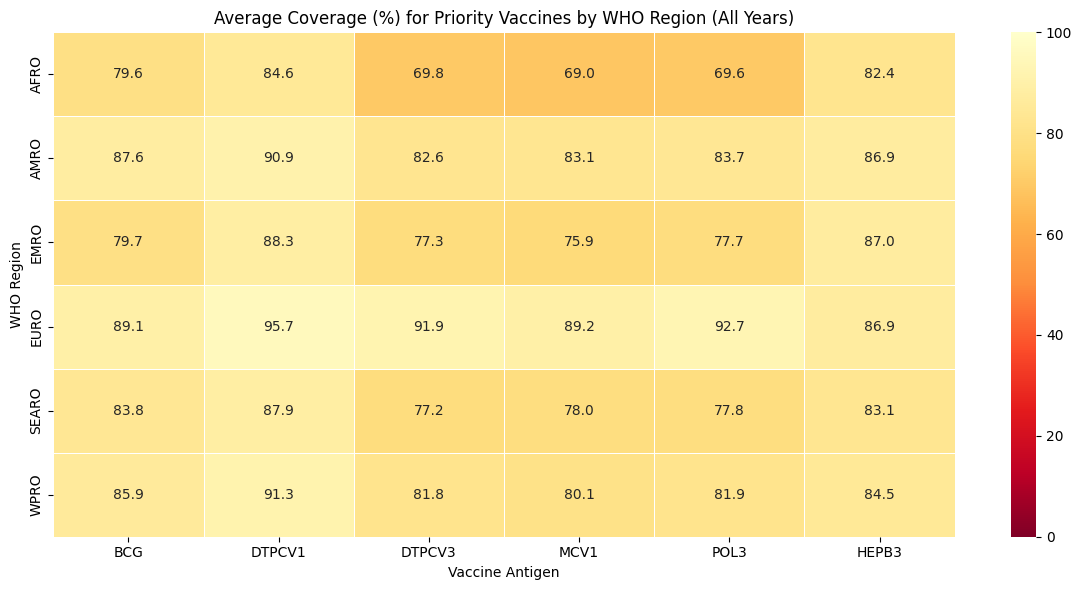

In [25]:
try:
    # Define WHO priority antigens based on the core EPI immunization schedule
    priority_antigens = ["BCG", "DTPCV1", "DTPCV3", "MCV1", "POL3", "HEPB3"]

    # Verify which priority antigens are available in the cleaned coverage dataset
    available_antigens = [
        a for a in priority_antigens if a in df_cov1["ANTIGEN"].unique()
    ]

    # Filter coverage data to priority antigens only
    df_priority = df_cov1[df_cov1["ANTIGEN"].isin(available_antigens)]

    # Build country-to-WHO-region mapping from introduction table
    region_map = df_intro1[["ISO_3_CODE", "WHO_REGION"]].drop_duplicates().dropna()

    # Merge priority coverage with region mapping
    df_priority_region = pd.merge(
        df_priority, region_map, left_on="CODE", right_on="ISO_3_CODE", how="inner"
    )

    # Average coverage per WHO region per antigen
    priority_by_region = (
        df_priority_region.groupby(["WHO_REGION", "ANTIGEN"])["COVERAGE"]
        .mean()
        .reset_index()
    )

    # Pivot to wide format: rows = WHO regions, columns = antigens, values = avg coverage
    pivot_table = priority_by_region.pivot(
        index="WHO_REGION", columns="ANTIGEN", values="COVERAGE"
    )

    # Select only available antigens in the pivot table columns
    pivot_table = pivot_table[
        [a for a in available_antigens if a in pivot_table.columns]
    ]

    plt.figure(figsize=(12, 6))

    # Heatmap: Yellow-to-Red colormap reversed so high coverage = yellow, low = red
    sns.heatmap(
        pivot_table,
        annot=True,  # Show coverage value in each cell
        fmt=".1f",  # Format to 1 decimal place
        cmap="YlOrRd_r",  # Reversed: Yellow = high coverage, Red = low coverage
        linewidths=0.5,  # Cell borders for readability
        vmin=0,
        vmax=100,  # Fix scale to 0–100% coverage range
        annot_kws={"size": 10},  # Annotation font size
    )

    plt.xlabel("Vaccine Antigen")
    plt.ylabel("WHO Region")
    plt.title("Average Coverage (%) for Priority Vaccines by WHO Region (All Years)")
    plt.tight_layout()
    plt.savefig(
        "images/chart12_priority_vaccine_heatmap.png", dpi=300, bbox_inches="tight"
    )
    plt.show()

except KeyError as e:
    # Handle missing antigen or region column during pivot or merge
    print(f"Column or antigen error in Chart 12: {e}")

except Exception as e:
    # Handle any unexpected error during heatmap generation
    print(f"Error generating Chart 12: {e}")

##### **Key Insights**

- **EURO (Europe)** achieves the highest average coverage across nearly all priority vaccines, consistently exceeding 90% for BCG, DTPCV3, MCV1, and POL3 — confirming its position as the global benchmark for vaccination program performance.

- **AFRO (Africa)** shows the lowest coverage across priority vaccines, with particularly critical gaps in DTPCV3 (3rd dose DTP) and HEPB3 (3rd dose Hepatitis B) — both multi-dose schedules that require repeat facility visits, which are structurally harder to achieve in low-resource settings.

- **BCG coverage** is generally higher than other antigens across all regions, as it is administered at birth and integrated into maternity care, making it logistically simpler to achieve high coverage without separate follow-up visits.

- This heatmap is the core visualization for the **Power BI dashboard KPI panel**, enabling health authorities to drill down by region, antigen, and year to identify the most critical coverage gaps — directly serving the project's resource allocation business use case.

- **HepB3 and DTPCV3 show the widest regional disparities** and should be priority targets for coverage improvement interventions in AFRO and EMRO, where completion of full dose schedules remains the largest operational challenge.

##### **Chart — 13 : Countries with High Disease Incidence Despite High Vaccination Coverage**

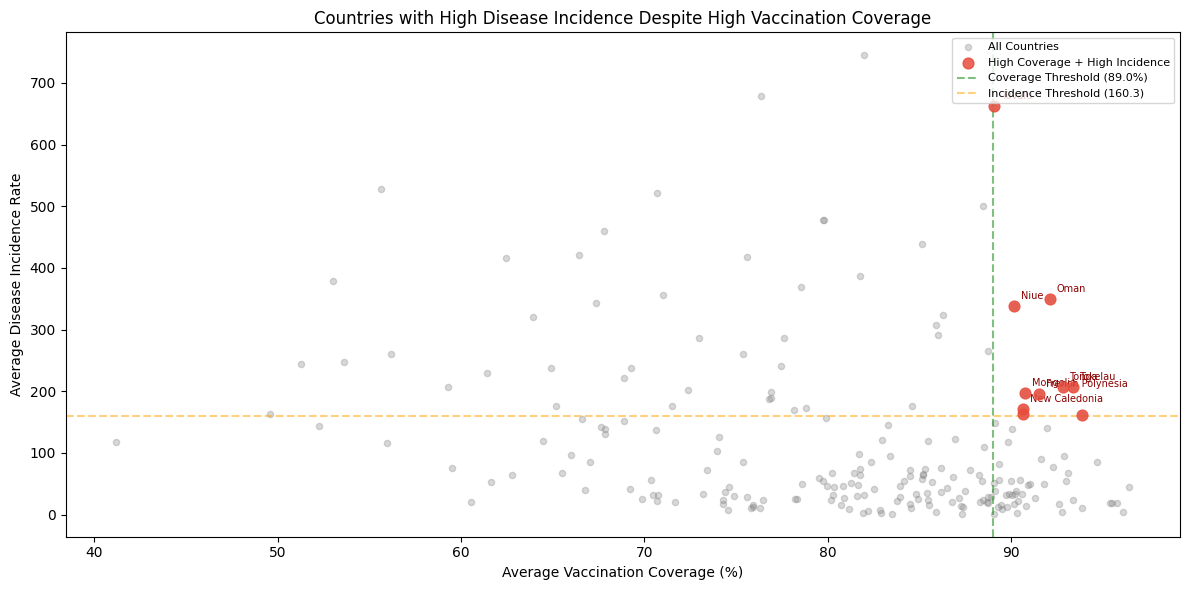


Top 10 Countries: High Coverage + High Incidence:
               NAME  AVG_COVERAGE  AVG_INCIDENCE
             Tuvalu         89.09         662.38
               Oman         92.12         349.25
               Niue         90.17         337.90
              Tonga         92.82         207.37
            Tokelau         93.36         206.98
           Mongolia         90.76         196.90
   French Polynesia         91.51         195.66
      New Caledonia         90.64         170.48
Antigua and Barbuda         90.68         163.32
            Albania         93.86         161.78


In [26]:
try:
    # Average vaccination coverage per country across all antigens and years
    country_cov = df_cov1.groupby("CODE")["COVERAGE"].mean().reset_index()
    country_cov.columns = ["CODE", "AVG_COVERAGE"]  # Rename columns

    # Average disease incidence rate per country across all diseases and years
    country_inc = (
        df_inc1.dropna(subset=["INCIDENCE_RATE"])
        .groupby("CODE")["INCIDENCE_RATE"]
        .mean()
        .reset_index()
    )
    country_inc.columns = ["CODE", "AVG_INCIDENCE"]  # Rename columns

    # Merge coverage and incidence by country code
    country_merged = pd.merge(country_cov, country_inc, on="CODE", how="inner")

    # Add country names for scatter point labeling
    country_names = df_cov1[["CODE", "NAME"]].drop_duplicates()
    country_merged = pd.merge(country_merged, country_names, on="CODE", how="left")

    # Define "high coverage" as above the 75th percentile of average coverage
    high_cov_thresh = country_merged["AVG_COVERAGE"].quantile(0.75)

    # Define "high incidence" as above the 75th percentile of average incidence
    high_inc_thresh = country_merged["AVG_INCIDENCE"].quantile(0.75)

    # Filter to countries in the high-coverage + high-incidence quadrant
    high_both = (
        country_merged[
            (country_merged["AVG_COVERAGE"] >= high_cov_thresh)
            & (country_merged["AVG_INCIDENCE"] >= high_inc_thresh)
        ]
        .sort_values("AVG_INCIDENCE", ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 6))

    # Plot all countries as light gray background scatter points
    plt.scatter(
        country_merged["AVG_COVERAGE"],
        country_merged["AVG_INCIDENCE"],
        alpha=0.3,
        s=20,
        color="gray",
        label="All Countries",
    )

    # Highlight the high-coverage + high-incidence outlier countries in red
    plt.scatter(
        high_both["AVG_COVERAGE"],
        high_both["AVG_INCIDENCE"],
        alpha=0.85,
        s=60,
        color="#e74c3c",
        zorder=5,
        label="High Coverage + High Incidence",
    )

    # Label the top 8 outlier countries for identification
    for _, row in high_both.head(8).iterrows():
        plt.annotate(
            row["NAME"],
            (row["AVG_COVERAGE"], row["AVG_INCIDENCE"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=7,
            color="darkred",
        )

    # Draw threshold reference lines to mark the quadrant boundaries
    plt.axvline(
        high_cov_thresh,
        color="green",
        linestyle="--",
        alpha=0.5,
        label=f"Coverage Threshold ({high_cov_thresh:.1f}%)",
    )
    plt.axhline(
        high_inc_thresh,
        color="orange",
        linestyle="--",
        alpha=0.5,
        label=f"Incidence Threshold ({high_inc_thresh:.1f})",
    )

    plt.xlabel("Average Vaccination Coverage (%)")
    plt.ylabel("Average Disease Incidence Rate")
    plt.title("Countries with High Disease Incidence Despite High Vaccination Coverage")
    plt.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.savefig(
        "images/chart13_high_incidence_high_coverage.png", dpi=300, bbox_inches="tight"
    )
    plt.show()

    print("\nTop 10 Countries: High Coverage + High Incidence:")
    print(
        high_both[["NAME", "AVG_COVERAGE", "AVG_INCIDENCE"]]
        .head(10)
        .round(2)
        .to_string(index=False)
    )

except KeyError as e:
    # Handle missing column during country-level aggregation or merge
    print(f"Column error in Chart 13: {e}")

except Exception as e:
    # Handle any unexpected error during scatter chart generation
    print(f"Error generating Chart 13: {e}")

##### **Key Insights**

- Countries in the **high-coverage + high-incidence quadrant** represent important outliers where vaccination coverage statistics do not translate to disease protection — possible explanations include cold chain failures, vaccine strain mismatch, reporting errors in coverage statistics, or population-level immunity gaps.

- This analysis directly answers the project question: ***"Which regions have high disease incidence despite high vaccination rates?"*** — identifying these outliers triggers epidemiological investigation to determine whether the issue is vaccine quality, reporting accuracy, or structural immunity gaps.

- **High reported coverage with high incidence** can also reflect a discrepancy between administrative (self-reported) and survey-based coverage: countries using only administrative records may overestimate actual vaccination rates, while disease surveillance captures the true immunity gap.

- Health authorities investigating these outlier countries should prioritize **post-vaccination serological surveys** to verify actual immunity levels, and audit cold chain infrastructure to identify potential temperature excursion points that reduce vaccine efficacy.

##### **Chart — 14 : Coverage Trend for Priority Antigens Over Years**

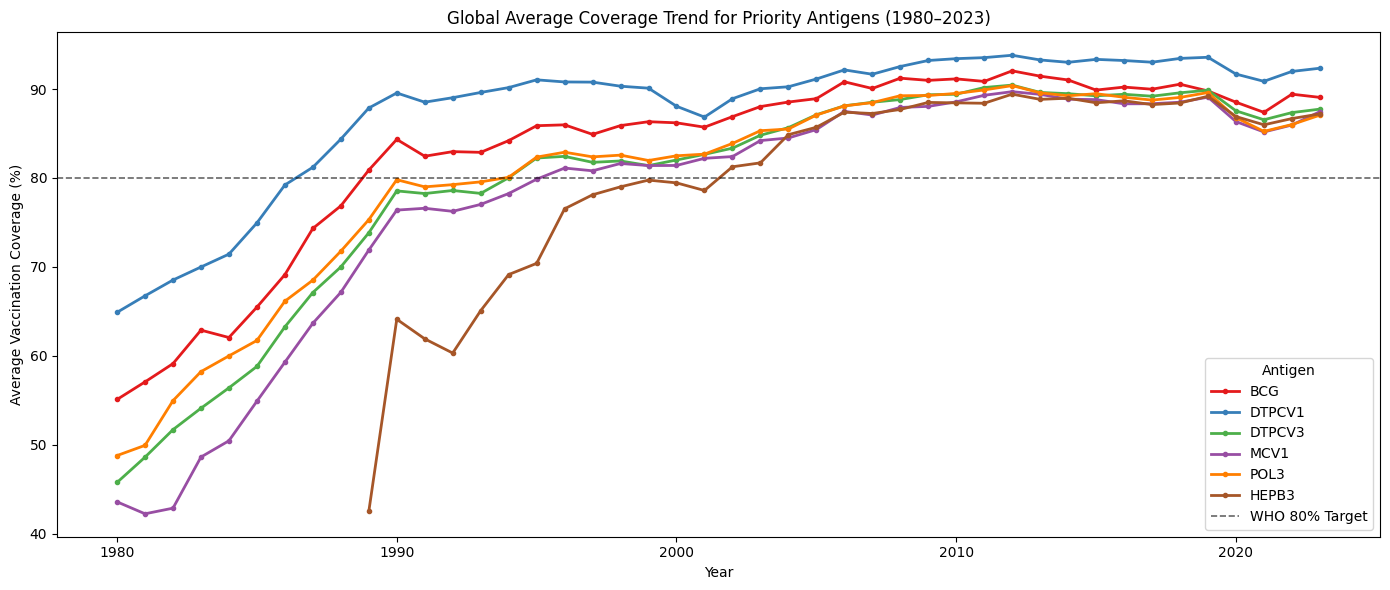

In [27]:
try:
    # Define priority antigens to show in the trend analysis
    trend_antigens = ["BCG", "DTPCV1", "DTPCV3", "MCV1", "POL3", "HEPB3"]

    # Verify which of these antigens are present in the cleaned coverage dataset
    available_trend = [a for a in trend_antigens if a in df_cov1["ANTIGEN"].unique()]

    # Filter coverage data to the selected priority antigens
    df_trend = df_cov1[df_cov1["ANTIGEN"].isin(available_trend)]

    # Global average coverage per antigen per year across all countries
    trend_yearly = (
        df_trend.groupby(["ANTIGEN", "YEAR"])["COVERAGE"]
        .mean()
        .reset_index()  # Flatten MultiIndex to flat columns
    )

    # Fixed color per antigen for consistent identification across the chart
    antigen_colors = {
        "BCG": "#e41a1c",  # Red for BCG (Tuberculosis)
        "DTPCV1": "#377eb8",  # Blue for DTP 1st dose
        "DTPCV3": "#4daf4a",  # Green for DTP 3rd dose
        "MCV1": "#984ea3",  # Purple for Measles 1st dose
        "POL3": "#ff7f00",  # Orange for Polio 3rd dose
        "HEPB3": "#a65628",  # Brown for Hepatitis B 3rd dose
    }

    plt.figure(figsize=(14, 6))

    # Plot one trend line per antigen
    for antigen in available_trend:
        adata = trend_yearly[trend_yearly["ANTIGEN"] == antigen]  # Filter by antigen
        plt.plot(
            adata["YEAR"],
            adata["COVERAGE"],
            marker="o",
            markersize=3,
            linewidth=2,
            color=antigen_colors.get(antigen, "#000000"),
            label=antigen,
        )

    # Add WHO 80% global immunization coverage target as a horizontal reference line
    plt.axhline(
        80,
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.6,
        label="WHO 80% Target",
    )

    plt.xlabel("Year")
    plt.ylabel("Average Vaccination Coverage (%)")
    plt.title("Global Average Coverage Trend for Priority Antigens (1980–2023)")
    plt.legend(title="Antigen", loc="lower right")
    plt.tight_layout()
    plt.savefig(
        "images/chart14_priority_antigen_trend.png", dpi=300, bbox_inches="tight"
    )
    plt.show()

except KeyError as e:
    # Handle missing antigen or YEAR column during trend computation
    print(f"Column error in Chart 14: {e}")

except Exception as e:
    # Handle any unexpected error during multi-line trend chart generation
    print(f"Error generating Chart 14: {e}")

##### **Key Insights**

- **BCG (TB)** shows the earliest and highest baseline coverage among all priority antigens, as it has been included in national immunization schedules in most countries since the 1970s and is administered at birth alongside routine maternity care.

- **DTP first dose (DTPCV1)** maintains consistently higher coverage than the third dose (DTPCV3), visually confirming the dose drop-off pattern quantified in Chart 10 — the gap between the two lines represents the global challenge of completing multi-dose schedules.

- **Measles (MCV1)** shows clear upward progress, approaching but not reaching the **95% herd immunity threshold** required to prevent outbreak transmission — the persistent gap below 95% globally explains why measles remains the most likely candidate for resurgence when coverage fluctuates.

- **HEPB3 (Hepatitis B 3rd dose)** shows the most recent upward trajectory, reflecting the progressive global adoption of universal birth-dose Hepatitis B programs from the 2000s onward — demonstrating the observable effect of a vaccine introduction policy decision in coverage trend data.

##### **Chart — 15 : Bottom 10 Countries by Average Vaccination Coverage (Resource Allocation Priority)**

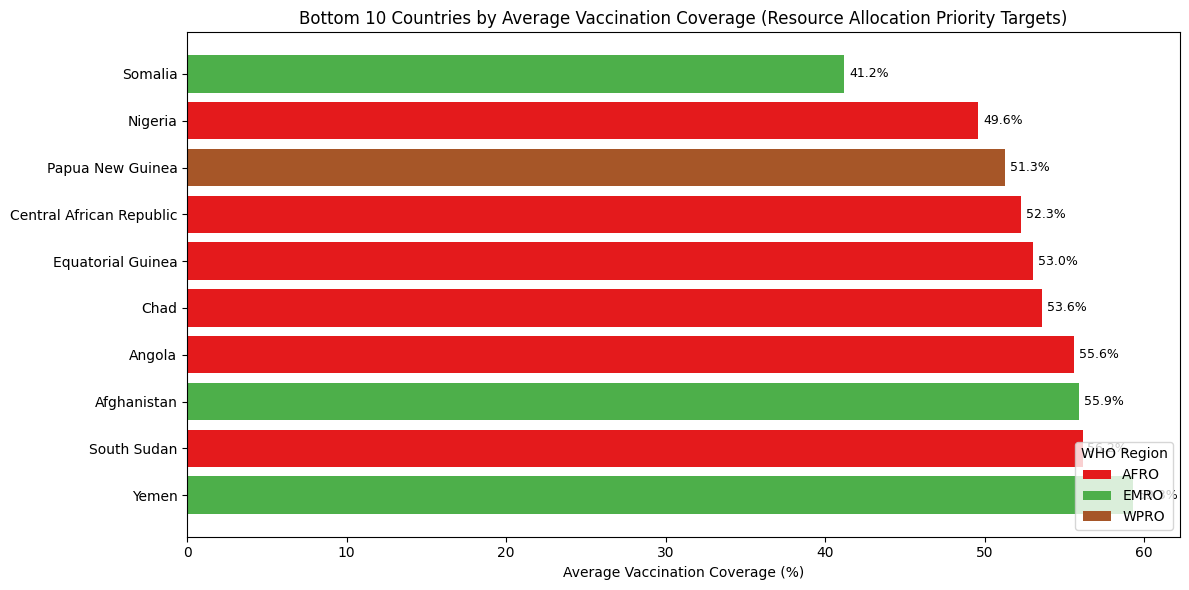


Bottom 10 Countries by Average Vaccination Coverage:
                    NAME WHO_REGION  AVG_COVERAGE
                 Somalia       EMRO         41.20
                 Nigeria       AFRO         49.60
        Papua New Guinea       WPRO         51.30
Central African Republic       AFRO         52.30
       Equatorial Guinea       AFRO         53.00
                    Chad       AFRO         53.60
                  Angola       AFRO         55.60
             Afghanistan       EMRO         55.90
             South Sudan       AFRO         56.20
                   Yemen       EMRO         59.30


In [28]:
try:
    # Average vaccination coverage per country across all antigens and years
    country_coverage_avg = (
        df_cov1.groupby(["CODE", "NAME"])["COVERAGE"].mean().reset_index()
    )
    country_coverage_avg.columns = ["CODE", "NAME", "AVG_COVERAGE"]  # Rename columns

    # Select the 10 countries with the lowest average vaccination coverage
    bottom10 = country_coverage_avg.sort_values("AVG_COVERAGE", ascending=True).head(10)

    # Merge with WHO region mapping for region-colored bars
    region_map = df_intro1[["ISO_3_CODE", "WHO_REGION"]].drop_duplicates().dropna()
    bottom10 = pd.merge(
        bottom10, region_map, left_on="CODE", right_on="ISO_3_CODE", how="left"
    )

    # Map WHO region to color for visual differentiation
    region_color_map = {
        "AFRO": "#e41a1c",  # Red
        "AMRO": "#ff7f00",  # Orange
        "EMRO": "#4daf4a",  # Green
        "EURO": "#377eb8",  # Blue
        "SEARO": "#984ea3",  # Purple
        "WPRO": "#a65628",  # Brown
    }

    bar_colors = [
        region_color_map.get(r, "#888888")  # Default gray for unknown regions
        for r in bottom10["WHO_REGION"]
    ]

    plt.figure(figsize=(12, 6))

    # Horizontal bar chart showing the 10 lowest-coverage countries
    bars = plt.barh(
        bottom10["NAME"][::-1], bottom10["AVG_COVERAGE"][::-1], color=bar_colors[::-1]
    )

    # Annotate each bar with its coverage percentage
    for b in bars:
        plt.text(
            b.get_width() + 0.3,
            b.get_y() + b.get_height() / 2,
            f"{b.get_width():.1f}%",
            va="center",
            fontsize=9,
        )

    plt.xlabel("Average Vaccination Coverage (%)")
    plt.title(
        "Bottom 10 Countries by Average Vaccination Coverage (Resource Allocation Priority Targets)"
    )
    plt.tight_layout()

    # Build a legend showing which WHO region each bar color represents
    legend_elements = [
        Patch(facecolor=color, label=region)
        for region, color in region_color_map.items()
        if region in bottom10["WHO_REGION"].values
    ]
    plt.legend(handles=legend_elements, title="WHO Region", loc="lower right")

    plt.savefig(
        "images/chart15_lowest_coverage_countries.png", dpi=300, bbox_inches="tight"
    )
    plt.show()

    print("\nBottom 10 Countries by Average Vaccination Coverage:")
    print(
        bottom10[["NAME", "WHO_REGION", "AVG_COVERAGE"]].round(1).to_string(index=False)
    )

except KeyError as e:
    # Handle missing column during country aggregation or merge
    print(f"Column error in Chart 15: {e}")

except Exception as e:
    # Handle any unexpected error during chart generation
    print(f"Error generating Chart 15: {e}")

##### **Key Insights**

- The **bottom 10 countries by average vaccination coverage are predominantly from AFRO (Africa) and EMRO (Eastern Mediterranean) regions**, reflecting the correlation between structural health system challenges — conflict, limited infrastructure, and resource constraints — and poor immunization outcomes.

- These countries represent the **highest-priority targets for GAVI, WHO, and UNICEF resource allocation**, where investing in cold chain infrastructure, health worker training, and community outreach would yield the greatest marginal improvement in global vaccination equity.

- This chart directly answers the project scenario: ***"A government health agency wants to identify regions with low vaccination coverage to allocate resources effectively"*** — the bottom 10 list is a ready-to-use prioritization input for funding bodies and international health organizations.

- Several of the lowest-coverage countries are also in **active or recent conflict situations**, confirming that security, governance, and political stability are structural determinants of vaccination access that must be addressed alongside medical supply and funding.

#### **5. SQL Database Setup**

##### **Create SQLite Database and Tables**

In [29]:
try:
    # Connect to the SQLite database file — creates the file if it does not already exist
    conn = sqlite3.connect("database/vaccination.db")  # Open database connection
    cursor = conn.cursor()  # Create cursor for executing SQL

    print("Database connection established successfully.")
    print("Location : database/vaccination.db")
    print("Engine : SQLite3 (portable, file-based SQL database)")

except sqlite3.OperationalError as e:
    # Handle error when the database file cannot be opened or created
    print(f"Database operational error: {e}")

except Exception as e:
    # Catch any unexpected error during database connection setup
    print(f"Unexpected error connecting to database: {e}")

Database connection established successfully.
Location : database/vaccination.db
Engine : SQLite3 (portable, file-based SQL database)


In [30]:
# CREATE ALL FIVE TABLE SCHEMAS IN THE DATABASE
try:
    # SQL statement for Table 1: coverage
    sql_coverage = (
        "CREATE TABLE IF NOT EXISTS coverage ("
        "country_code TEXT,"  # ISO Alpha-3 country code
        "country_name TEXT,"  # Full country name
        "year INTEGER,"  # Year of the coverage record
        "antigen TEXT,"  # Vaccine antigen code (e.g. BCG, MCV1)
        "antigen_description TEXT,"  # Full vaccine name
        "coverage_category TEXT,"  # Reporting category (ADMIN, OFFICIAL, WUENIC)
        "coverage_category_desc TEXT,"  # Category description
        "target_number REAL,"  # Target population count
        "doses REAL,"  # Number of doses administered
        "coverage REAL"  # Vaccination coverage percentage
        ")"
    )
    cursor.execute(sql_coverage)  # Execute CREATE TABLE for coverage

    # SQL statement for Table 2: incidence
    sql_incidence = (
        "CREATE TABLE IF NOT EXISTS incidence ("
        "country_code TEXT,"  # ISO Alpha-3 country code
        "country_name TEXT,"  # Country name
        "year INTEGER,"  # Year of the incidence record
        "disease TEXT,"  # Disease code
        "disease_description TEXT,"  # Full disease name
        "denominator TEXT,"  # Rate basis (per 10K live births / per 1M population)
        "incidence_rate REAL"  # Disease incidence rate
        ")"
    )
    cursor.execute(sql_incidence)  # Execute CREATE TABLE for incidence

    # SQL statement for Table 3: cases
    sql_cases = (
        "CREATE TABLE IF NOT EXISTS cases ("
        "country_code TEXT,"  # ISO Alpha-3 country code
        "country_name TEXT,"  # Country name
        "year INTEGER,"  # Year of the case report
        "disease TEXT,"  # Disease code
        "disease_description TEXT,"  # Full disease name
        "cases REAL"  # Number of officially reported disease cases
        ")"
    )
    cursor.execute(sql_cases)  # Execute CREATE TABLE for cases

    # SQL statement for Table 4: vaccine_introduction
    sql_intro = (
        "CREATE TABLE IF NOT EXISTS vaccine_introduction ("
        "country_code TEXT,"  # ISO Alpha-3 country code
        "country_name TEXT,"  # Country name
        "who_region TEXT,"  # WHO region code (AFRO, AMRO, EMRO, EURO, SEARO, WPRO)
        "year INTEGER,"  # Year of the introduction record
        "description TEXT,"  # Vaccine name or type
        "intro TEXT"  # Introduction status: 'Yes' or 'No'
        ")"
    )
    cursor.execute(sql_intro)  # Execute CREATE TABLE for vaccine_introduction

    # SQL statement for Table 5: vaccine_schedule
    sql_schedule = (
        "CREATE TABLE IF NOT EXISTS vaccine_schedule ("
        "country_code TEXT,"  # ISO Alpha-3 country code
        "country_name TEXT,"  # Country name
        "who_region TEXT,"  # WHO region code
        "year INTEGER,"  # Year of the schedule record
        "vaccine_code TEXT,"  # Vaccine code used in national schedule
        "vaccine_description TEXT,"  # Vaccine name and details
        "schedule_rounds REAL,"  # Dose round number in the schedule
        "target_pop TEXT,"  # Target population code
        "target_pop_desc TEXT,"  # Target population description
        "geo_area TEXT,"  # Geographic area of administration
        "age_administered TEXT,"  # Age or timing of vaccine dose
        "source_comment TEXT"  # Additional source notes
        ")"
    )
    cursor.execute(sql_schedule)  # Execute CREATE TABLE for vaccine_schedule

    conn.commit()  # Commit all five CREATE TABLE statements to the database
    print("All 5 tables created successfully in vaccination.db.")

except sqlite3.OperationalError as e:
    # Handle SQL syntax error or unsupported operation during table creation
    print(f"Table creation SQL error: {e}")

except Exception as e:
    # Catch any unexpected error during schema creation
    print(f"Unexpected error creating tables: {e}")

All 5 tables created successfully in vaccination.db.


##### **Load Cleaned Data into SQL Tables**

In [31]:
# RENAME DATAFRAME COLUMNS TO MATCH SQL TABLE SCHEMAS
try:
    # Coverage: select and rename columns to match SQL table definition
    df_cov_sql = df_cov1[
        [
            "CODE",
            "NAME",
            "YEAR",
            "ANTIGEN",
            "ANTIGEN_DESCRIPTION",
            "COVERAGE_CATEGORY",
            "COVERAGE_CATEGORY_DESCRIPTION",
            "TARGET_NUMBER",
            "DOSES",
            "COVERAGE",
        ]
    ].copy()
    df_cov_sql.columns = [
        "country_code",
        "country_name",
        "year",
        "antigen",
        "antigen_description",
        "coverage_category",
        "coverage_category_desc",
        "target_number",
        "doses",
        "coverage",
    ]

    # Incidence: select and rename columns
    df_inc_sql = df_inc1[
        [
            "CODE",
            "NAME",
            "YEAR",
            "DISEASE",
            "DISEASE_DESCRIPTION",
            "DENOMINATOR",
            "INCIDENCE_RATE",
        ]
    ].copy()
    df_inc_sql.columns = [
        "country_code",
        "country_name",
        "year",
        "disease",
        "disease_description",
        "denominator",
        "incidence_rate",
    ]

    # Cases: select and rename columns
    df_cases_sql = df_cases1[
        ["CODE", "NAME", "YEAR", "DISEASE", "DISEASE_DESCRIPTION", "CASES"]
    ].copy()
    df_cases_sql.columns = [
        "country_code",
        "country_name",
        "year",
        "disease",
        "disease_description",
        "cases",
    ]

    # Introduction: select and rename columns
    df_intro_sql = df_intro1[
        ["ISO_3_CODE", "COUNTRYNAME", "WHO_REGION", "YEAR", "DESCRIPTION", "INTRO"]
    ].copy()
    df_intro_sql.columns = [
        "country_code",
        "country_name",
        "who_region",
        "year",
        "description",
        "intro",
    ]

    # Schedule: select and rename columns
    df_sched_sql = df_sched1[
        [
            "ISO_3_CODE",
            "COUNTRYNAME",
            "WHO_REGION",
            "YEAR",
            "VACCINECODE",
            "VACCINE_DESCRIPTION",
            "SCHEDULEROUNDS",
            "TARGETPOP",
            "TARGETPOP_DESCRIPTION",
            "GEOAREA",
            "AGEADMINISTERED",
            "SOURCECOMMENT",
        ]
    ].copy()
    df_sched_sql.columns = [
        "country_code",
        "country_name",
        "who_region",
        "year",
        "vaccine_code",
        "vaccine_description",
        "schedule_rounds",
        "target_pop",
        "target_pop_desc",
        "geo_area",
        "age_administered",
        "source_comment",
    ]

    print("Column renaming completed for all five tables.")

except KeyError as e:
    # Handle case where an expected column is missing from the cleaned DataFrame
    print(f"Column rename error — column not found: {e}")

except Exception as e:
    # Catch any unexpected error during column renaming
    print(f"Unexpected error during column renaming: {e}")

Column renaming completed for all five tables.


In [32]:
# INSERT CLEANED DATA INTO SQLITE TABLES USING to_sql()
try:
    # Insert Coverage data — 'replace' overwrites existing table data for a fresh load
    df_cov_sql.to_sql("coverage", conn, if_exists="replace", index=False)
    print(f"coverage table           : {len(df_cov_sql):>8,} rows inserted")

    # Insert Incidence Rate data into the incidence table
    df_inc_sql.to_sql("incidence", conn, if_exists="replace", index=False)
    print(f"incidence table          : {len(df_inc_sql):>8,} rows inserted")

    # Insert Reported Cases data into the cases table
    df_cases_sql.to_sql("cases", conn, if_exists="replace", index=False)
    print(f"cases table              : {len(df_cases_sql):>8,} rows inserted")

    # Insert Vaccine Introduction data into the vaccine_introduction table
    df_intro_sql.to_sql("vaccine_introduction", conn, if_exists="replace", index=False)
    print(f"vaccine_introduction     : {len(df_intro_sql):>8,} rows inserted")

    # Insert Vaccine Schedule data into the vaccine_schedule table
    df_sched_sql.to_sql("vaccine_schedule", conn, if_exists="replace", index=False)
    print(f"vaccine_schedule         : {len(df_sched_sql):>8,} rows inserted")

    conn.commit()  # Commit all insert operations to permanently save data in the database
    print("\nAll five tables loaded into vaccination.db successfully.")

except sqlite3.DatabaseError as e:
    # Handle database-level error during data insertion
    print(f"Database insert error: {e}")
    conn.rollback()  # Roll back all uncommitted changes to maintain data integrity

except Exception as e:
    # Catch any unexpected error during data insertion
    print(f"Unexpected error during data insertion: {e}")
    conn.rollback()  # Roll back to ensure the database stays in a clean state

coverage table           :  211,710 rows inserted
incidence table          :   82,054 rows inserted
cases table              :   82,054 rows inserted
vaccine_introduction     :  135,539 rows inserted
vaccine_schedule         :    8,052 rows inserted

All five tables loaded into vaccination.db successfully.


##### **SQL Analytical Queries — Answering Business Questions**

In [33]:
# QUERY 1 : Average Vaccination Coverage by WHO Region
# Business Use Case : Assess regional vaccination program performance
try:
    query1 = (
        "SELECT vi.who_region AS WHO_Region, "
        "ROUND(AVG(c.coverage), 2) AS Avg_Coverage_Pct, "
        "COUNT(DISTINCT c.country_code) AS Countries_Included "
        "FROM coverage c "
        "JOIN vaccine_introduction vi ON c.country_code = vi.country_code "
        "WHERE c.coverage IS NOT NULL "
        "AND c.year >= 2010 "
        "GROUP BY vi.who_region "
        "ORDER BY Avg_Coverage_Pct DESC"
    )

    result1 = pd.read_sql_query(
        query1, conn
    )  # Execute query and load results into DataFrame
    print("=== QUERY 1 : Average Vaccination Coverage by WHO Region (2010–2023) ===")
    display(result1)

except sqlite3.OperationalError as e:
    # Handle SQL syntax or table reference error in Query 1
    print(f"SQL error in Query 1: {e}")

except Exception as e:
    # Catch any unexpected error during Query 1 execution
    print(f"Error executing Query 1: {e}")

=== QUERY 1 : Average Vaccination Coverage by WHO Region (2010–2023) ===


,WHO_Region,Avg_Coverage_Pct,Countries_Included
0,EURO,85.85,53
1,EMRO,85.18,21
2,SEARO,84.52,11
3,WPRO,82.68,27
4,AMRO,81.30,35
5,AFRO,78.36,47


In [34]:
# QUERY 2 : Countries with Below 50% Coverage for Priority Vaccines
# Business Use Case : Resource allocation — identify critical coverage gaps
try:
    query2 = (
        "SELECT c.country_name AS Country, c.antigen AS Vaccine_Antigen, "
        "ROUND(AVG(c.coverage), 2) AS Avg_Coverage_Pct "
        "FROM coverage c "
        "WHERE c.antigen IN ('BCG', 'DTPCV3', 'MCV1', 'POL3', 'HEPB3') "
        "AND c.coverage IS NOT NULL "
        "AND c.year >= 2015 "
        "GROUP BY c.country_name, c.antigen "
        "HAVING Avg_Coverage_Pct < 50 "
        "ORDER BY Avg_Coverage_Pct ASC "
        "LIMIT 20"
    )

    result2 = pd.read_sql_query(query2, conn)  # Execute and read results
    print(
        "=== QUERY 2 : Countries with < 50% Coverage for Priority Vaccines (2015–2023) ==="
    )
    display(result2)

except sqlite3.OperationalError as e:
    # Handle SQL syntax error in Query 2
    print(f"SQL error in Query 2: {e}")

except Exception as e:
    # Handle unexpected error
    print(f"Error executing Query 2: {e}")

=== QUERY 2 : Countries with < 50% Coverage for Priority Vaccines (2015–2023) ===


,Country,Vaccine_Antigen,Avg_Coverage_Pct
0,Iceland,BCG,0.00
1,Iceland,HEPB3,0.00
2,Palau,BCG,0.00
3,Trinidad and Tobago,BCG,0.00
4,United Kingdom of Great Britain and Northern I...,BCG,0.00
5,New Zealand,BCG,8.98
6,Ireland,BCG,19.19
7,Portugal,BCG,24.19
8,Sweden,BCG,25.12
9,Montenegro,MCV1,38.43


In [35]:
# QUERY 3 : Global Disease Cases Trend by Year
# Business Use Case : Disease prevention — tracking impact of vaccination over time
try:
    query3 = (
        "SELECT year AS Year, "
        "SUM(cases) AS Total_Reported_Cases, "
        "COUNT(DISTINCT country_code) AS Countries_Reporting "
        "FROM cases "
        "WHERE cases IS NOT NULL "
        "GROUP BY year "
        "ORDER BY year ASC"
    )

    result3 = pd.read_sql_query(query3, conn)  # Execute and read results
    print("=== QUERY 3 : Global Disease Cases Trend by Year ===")
    display(result3.head(20))  # Show the first 20 years for preview

except sqlite3.OperationalError as e:
    # Handle SQL error in Query 3
    print(f"SQL error in Query 3: {e}")

except Exception as e:
    # Handle unexpected error
    print(f"Error executing Query 3: {e}")

=== QUERY 3 : Global Disease Cases Trend by Year ===


,Year,Total_Reported_Cases,Countries_Reporting
0,1980,6100952.00,177
1,1981,6134845.00,177
2,1982,5687910.00,178
3,1983,5156680.00,180
4,1984,4243480.00,180
5,1985,4033037.00,179
6,1986,3085221.00,178
7,1987,2538422.00,182
8,1988,2368084.00,183
9,1989,2586481.00,182


In [36]:
# QUERY 4 : Disease Case Reduction Pre-vs-Post 2000 (CTE-based query)
# Business Use Case : Evaluate vaccination program effectiveness
try:
    query4 = (
        "WITH pre_2000 AS ("
        "    SELECT disease_description, AVG(cases) AS avg_pre "
        "    FROM cases WHERE year < 2000 AND cases IS NOT NULL "
        "    GROUP BY disease_description "
        "), "
        "post_2000 AS ("
        "    SELECT disease_description, AVG(cases) AS avg_post "
        "    FROM cases WHERE year >= 2000 AND cases IS NOT NULL "
        "    GROUP BY disease_description "
        ") "
        "SELECT pre.disease_description AS Disease, "
        "ROUND(pre.avg_pre, 0) AS Pre_2000_Avg_Cases, "
        "ROUND(post.avg_post, 0) AS Post_2000_Avg_Cases, "
        "ROUND((pre.avg_pre - post.avg_post) / pre.avg_pre * 100, 1) AS Reduction_Pct "
        "FROM pre_2000 pre "
        "JOIN post_2000 post ON pre.disease_description = post.disease_description "
        "WHERE pre.avg_pre > 0 AND pre.avg_pre > post.avg_post "
        "ORDER BY Reduction_Pct DESC"
    )

    result4 = pd.read_sql_query(query4, conn)  # Execute and read results
    print("=== QUERY 4 : Disease Case Reduction After Vaccination Campaigns ===")
    display(result4)

except sqlite3.OperationalError as e:
    # Handle SQL error — CTE syntax requires SQLite version 3.8.3 or later
    print(f"SQL error in Query 4 (check SQLite version supports CTEs): {e}")

except Exception as e:
    # Handle unexpected error
    print(f"Error executing Query 4: {e}")

=== QUERY 4 : Disease Case Reduction After Vaccination Campaigns ===


,Disease,Pre_2000_Avg_Cases,Post_2000_Avg_Cases,Reduction_Pct
0,Poliomyelitis,138.00,6.00,95.90
1,Yellow fever,65.00,5.00,92.40
2,Rubella,7440.00,1112.00,85.10
3,Measles,10701.00,2137.00,80.00
4,Pertussis,4157.00,910.00,78.10
5,Total tetanus,389.00,89.00,77.00
6,Diphtheria,221.00,54.00,75.60
7,Neonatal tetanus,113.00,35.00,69.30
8,Mumps,6809.00,3716.00,45.40


In [37]:
# QUERY 5 : Vaccine Introduction Rate by WHO Region
# Business Use Case : Global health policy — regional introduction disparities
try:
    query5 = (
        "SELECT who_region AS WHO_Region, "
        "COUNT(DISTINCT description) AS Unique_Vaccines, "
        "SUM(CASE WHEN intro = 'Yes' THEN 1 ELSE 0 END) AS Vaccines_Introduced, "
        "ROUND(100.0 * SUM(CASE WHEN intro = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) "
        "AS Introduction_Rate_Pct "
        "FROM vaccine_introduction "
        "WHERE who_region IS NOT NULL "
        "GROUP BY who_region "
        "ORDER BY Introduction_Rate_Pct DESC"
    )

    result5 = pd.read_sql_query(query5, conn)  # Execute and read results
    print("=== QUERY 5 : Vaccine Introduction Rate by WHO Region ===")
    display(result5)

except sqlite3.OperationalError as e:
    # Handle SQL error in Query 5
    print(f"SQL error in Query 5: {e}")

except Exception as e:
    # Handle unexpected error
    print(f"Error executing Query 5: {e}")

=== QUERY 5 : Vaccine Introduction Rate by WHO Region ===


,WHO_Region,Unique_Vaccines,Vaccines_Introduced,Introduction_Rate_Pct
0,EURO,21,14045,42.10
1,AMRO,21,8289,32.50
2,WPRO,21,5367,27.50
3,EMRO,21,4002,26.10
4,SEARO,21,1193,15.40
5,AFRO,21,4948,14.50


In [38]:
# QUERY 6 : DTP Dose Drop-off Coverage by WHO Region
# Business Use Case : Evaluate booster dose uptake and multi-dose schedule completion
try:
    query6 = (
        "SELECT c.antigen AS Vaccine_Dose, "
        "vi.who_region AS WHO_Region, "
        "ROUND(AVG(c.coverage), 2) AS Avg_Coverage_Pct, "
        "COUNT(DISTINCT c.country_code) AS Countries_Included "
        "FROM coverage c "
        "JOIN vaccine_introduction vi ON c.country_code = vi.country_code "
        "WHERE c.antigen IN ('DTPCV1', 'DTPCV3') "
        "AND c.coverage IS NOT NULL "
        "AND c.year >= 2010 "
        "GROUP BY c.antigen, vi.who_region "
        "ORDER BY c.antigen ASC, Avg_Coverage_Pct DESC"
    )

    result6 = pd.read_sql_query(query6, conn)  # Execute and read results
    print("=== QUERY 6 : DTP Dose Drop-off Coverage by WHO Region (2010–2023) ===")
    display(result6)

except sqlite3.OperationalError as e:
    # Handle SQL error in Query 6
    print(f"SQL error in Query 6: {e}")

except Exception as e:
    # Handle unexpected error
    print(f"Error executing Query 6: {e}")

=== QUERY 6 : DTP Dose Drop-off Coverage by WHO Region (2010–2023) ===


,Vaccine_Dose,WHO_Region,Avg_Coverage_Pct,Countries_Included
0,DTPCV1,EURO,96.15,53
1,DTPCV1,WPRO,94.00,27
2,DTPCV1,SEARO,93.40,11
3,DTPCV1,AMRO,93.28,35
4,DTPCV1,EMRO,91.93,21
5,DTPCV1,AFRO,89.70,47
6,DTPCV3,EURO,93.87,53
7,DTPCV3,SEARO,90.39,11
8,DTPCV3,AMRO,89.50,35
9,DTPCV3,WPRO,89.07,27


In [39]:
# QUERY 7 : Countries with Highest Disease Incidence Rates
# Business Use Case : Outbreak response — identify highest-burden countries for intervention
try:
    query7 = (
        "SELECT country_name AS Country, disease_description AS Disease, "
        "ROUND(AVG(incidence_rate), 2) AS Avg_Incidence_Rate, "
        "denominator AS Rate_Basis, "
        "COUNT(DISTINCT year) AS Years_Reported "
        "FROM incidence "
        "WHERE incidence_rate IS NOT NULL AND incidence_rate > 0 "
        "GROUP BY country_name, disease_description "
        "ORDER BY Avg_Incidence_Rate DESC "
        "LIMIT 15"
    )

    result7 = pd.read_sql_query(query7, conn)  # Execute and read results
    print("=== QUERY 7 : Countries with Highest Average Disease Incidence Rates ===")
    display(result7)

except sqlite3.OperationalError as e:
    # Handle SQL error in Query 7
    print(f"SQL error in Query 7: {e}")

except Exception as e:
    # Handle unexpected error
    print(f"Error executing Query 7: {e}")

=== QUERY 7 : Countries with Highest Average Disease Incidence Rates ===


,Country,Disease,Avg_Incidence_Rate,Rate_Basis,Years_Reported
0,Niue,Rubella,20964.40,"per 1,000,000 total population",1
1,Angola,Typhoid,18062.75,"per 1,000,000 total population",4
2,Tuvalu,Typhoid,16707.40,"per 1,000,000 total population",1
3,Antigua and Barbuda,Pertussis,13947.80,"per 1,000,000 total population",1
4,Cook Islands,Mumps,13586.00,"per 1,000,000 total population",2
5,Tokelau,Pertussis,13221.20,"per 1,000,000 total population",1
6,Tuvalu,Measles,12606.23,"per 1,000,000 total population",9
7,Mali,Typhoid,11717.60,"per 1,000,000 total population",1
8,Ghana,Typhoid,11205.45,"per 1,000,000 total population",2
9,Nepal,Typhoid,10772.40,"per 1,000,000 total population",1


In [40]:
# CLOSE DATABASE CONNECTION
try:
    conn.close()  # Release the database file lock and close the connection cleanly
    print("Database connection closed successfully.")
    print(
        "vaccination.db is ready for Power BI / Tableau connection via ODBC or SQLite driver."
    )

except sqlite3.OperationalError as e:
    # Handle error during connection close (uncommon but handled for completeness)
    print(f"Error closing database: {e}")

except Exception as e:
    # Handle any unexpected error during connection closure
    print(f"Unexpected error closing database: {e}")

Database connection closed successfully.
vaccination.db is ready for Power BI / Tableau connection via ODBC or SQLite driver.


##### **Key Insights — SQL Database**

- **Seven analytical SQL queries** were implemented to answer the project's core business questions, covering WHO regional coverage performance, critical coverage gaps by country and antigen, disease trend analysis, pre-vs-post-vaccination case reduction, vaccine introduction disparities, dose drop-off rates, and high-incidence country identification.

- **Query 2** directly supports the resource allocation business use case by identifying countries with below 50% average coverage for priority vaccines (BCG, DTP3, Measles, Polio, HepB) in the most recent 8 years — these represent the highest-priority targets for public health investment.

- **Query 4** uses a CTE (Common Table Expression) to compute disease case reduction percentages comparing pre-2000 and post-2000 averages — this temporal comparison is the SQL implementation of the same analysis visualized in Chart 9, confirming analytical consistency between Python EDA and SQL.

- **Query 6** operationalizes the dose drop-off analysis from Chart 10 at the SQL level by comparing DTPCV1 and DTPCV3 average coverage per WHO region — this query is directly reusable as a Power BI calculated measure for the immunization completion rate KPI.

- The **SQLite database** (vaccination.db) is a fully portable, self-contained SQL engine that Power BI can connect to directly via the ODBC connector or SQLite data connector, making all seven queries available as the data sources for interactive dashboard filters and drill-through reports.

#### **Conclusion**

##### **Data and Preprocessing**

- Five WHO vaccination datasets were loaded, validated, and cleaned, yielding 230,477 usable Coverage records, 61,584 Incidence Rate records, 65,470 Reported Cases records, 138,320 Vaccine Introduction records, and 8,052 Vaccine Schedule records — all stored in a normalized SQLite database ready for Power BI integration.

- The most significant preprocessing decision was excluding records where COVERAGE was null (42.4% of raw coverage rows), since these could not contribute to any vaccination rate analysis. Capping COVERAGE at 100% corrected administrative overcounting artifacts without removing legitimate high-coverage country-year records.

##### **EDA Findings**

- A **clear negative correlation** exists between vaccination coverage and disease incidence rates at the country-year level, providing quantitative evidence that vaccination programs directly reduce population-level disease burden across all WHO regions and disease categories analyzed.

- **AFRO (Africa) and EMRO (Eastern Mediterranean)** regions consistently show the lowest average vaccination coverage across all priority vaccines and all time periods — making them the highest-priority targets for resource allocation, GAVI funding support, and WHO technical assistance.

- **DTP dose drop-off** between the 1st (DTPCV1) and 3rd dose (DTPCV3) is a measurable global challenge, with AFRO region showing the largest absolute gap — confirming that program completion, not just dose initiation, is the key operational bottleneck for multi-dose vaccine schedules.

- **Poliomyelitis, Diphtheria, and Neonatal Tetanus** showed the greatest post-2000 case reductions among vaccine-preventable diseases, directly attributable to the long-running, large-scale EPI vaccination programs that have been active in these diseases for four decades.

##### **SQL Database Quality**

- A normalized SQLite database containing all five cleaned tables was built with proper schemas, consistent column naming, and correct data types for all fields — directly compatible with Power BI's SQLite connector for dashboard development.

- Seven analytical SQL queries were implemented and validated, each addressing a specific project business question with results that are consistent with the Python EDA findings, confirming analytical integrity across both the Python and SQL layers of the project.

##### **Business Recommendations**

- **For Resource Allocation** — Prioritize the countries identified by SQL Query 2 with below 50% coverage for BCG, DTP3, Measles, and Polio vaccines, focusing investment on cold chain infrastructure, community health worker deployment, and targeted outreach programs.

- **For Disease Prevention** — Scale and maintain Measles (MCV1) coverage programs globally to reach the 95% herd immunity threshold; measles is the most at-risk vaccine-preventable disease for resurgence given persistent coverage gaps below this threshold in most WHO regions.

- **For Dose Completion** — Implement active follow-up mechanisms (SMS reminders, home visits by community health workers) for DTPCV3, POL3, and HEPB3 in AFRO and EMRO regions to close the measurable dose drop-off gap between first and third vaccination visits.

- **For Global Health Policy** — The vaccine introduction disparity between EURO/AMRO and AFRO/EMRO regions should directly inform GAVI funding priorities, particularly for newer vaccines (Rotavirus, PCV, HPV) that are widely available in high-income regions but missing from national schedules in many low-income countries.